# 02 · Exploración de datos (EDA) — entender los datos

**Objetivo:** antes de analizar el estilo del entrenador, entender *qué hay* en cada tabla: granularidad, tipo de cada columna, distribuciones, faltantes, relaciones entre variables y limitaciones.

Para cada tabla:
- **Numéricas** → count, % nulos, min, percentiles, media, mediana, máx, desviación, **moda**, % ceros, asimetría + histogramas + **correlaciones** (Spearman).
- **Categóricas** → n categorías, **moda** y su %, **% de cada categoría** + barras + asociación entre categóricas (**V de Cramér**).
- **Booleanas** (flags) → % de `True`. ⚠️ En StatsBomb un flag ausente (`NaN`) significa **False**.

| Tabla | Granularidad |
|---|---|
| `matches` | 1 fila = 1 partido del América |
| `events` | 1 fila = 1 evento (ambos equipos) |
| `team_match_stats` | 1 fila = 1 equipo × partido |
| `player_match_stats` | 1 fila = 1 jugador × partido |
| `lineups` | 1 fila = 1 jugador convocado × partido |
| `frames360` | 1 fila = 1 jugador visible × evento |

Las tablas de perfil se guardan en `data/processed/eda/` (CSV) y las figuras en `reports/figures/eda/`.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from mplsoccer import Pitch

from src.sb_client import RAW, PROCESSED, load_dataset
from src import eda

eda.set_style()
pd.set_option("display.max_columns", 60, "display.max_rows", 250, "display.width", 250,
              "display.float_format", lambda v: f"{v:,.3f}")

TEAM = "América"
OUT = PROCESSED / "eda"; OUT.mkdir(parents=True, exist_ok=True)
FIG = ROOT / "reports" / "figures" / "eda"; FIG.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

def show(df, name, n=None):
    df.to_csv(OUT / f"{name}.csv")
    display(df if n is None else df.head(n))

## 0. Carga de datos

In [2]:
matches = pd.read_parquet(RAW / "matches_america.parquet")
played = matches[matches.match_status == "available"].copy()
ctx = played[["match_id", "match_date", "season", "match_week", "team_manager", "opponent",
              "is_home", "goals_for", "goals_against", "result"]]

def load(name):
    """Usa data/processed si existe (salida del notebook 01); si no, arma desde data/raw."""
    p = PROCESSED / f"{name}_america.parquet"
    if p.exists():
        return pd.read_parquet(p)
    return load_dataset(name).merge(ctx, on="match_id", how="left")

events = load("events")
team_stats = load("team_match_stats")
player_stats = load("player_match_stats")
lineups = load("lineups")

inventory = pd.DataFrame({
    name: {"filas": len(df), "columnas": df.shape[1], "partidos": df.match_id.nunique(),
           "memoria_MB": round(df.memory_usage(deep=True).sum() / 1e6, 1)}
    for name, df in {"matches": played, "events": events, "team_match_stats": team_stats,
                     "player_match_stats": player_stats, "lineups": lineups}.items()}).T
inventory

,filas,columnas,partidos,memoria_MB
matches,222.000,69.000,222.000,0.200
events,"736,829.000",162.000,222.000,"2,549.800"
team_match_stats,442.000,216.000,221.000,0.800
player_match_stats,"6,870.000",187.000,222.000,10.800
lineups,"9,317.000",25.000,222.000,16.900


### Cobertura: ¿tenemos todos los partidos?
Partidos jugados vs. partidos con eventos y con 360, por temporada y entrenador.

In [3]:
n360 = {int(p.stem) for p in (RAW / "frames360").glob("*.parquet")}
cov = (played.assign(con_eventos=played.match_id.isin(events.match_id.unique()),
                     con_360=played.match_id.isin(n360))
       .groupby(["season", "team_manager"])
       .agg(jugados=("match_id", "size"), con_eventos=("con_eventos", "sum"), con_360=("con_360", "sum"),
            desde=("match_date", "min"), hasta=("match_date", "max")))
show(cov, "cobertura")

jugados  con_eventos  con_360       desde       hasta
season    team_manager                                                                         
2021/2022 Fernando Ortiz                       13           13       13  2022-03-06  2022-05-23
          Santiago Hernán Solari Poggio        27           27       27  2021-07-23  2022-03-02
2022/2023 Fernando Ortiz                       42           42       42  2022-07-03  2023-05-22
2023/2024 André Soares Jardine                 46           46       46  2023-07-01  2024-05-27
2024/2025 André Soares Jardine                 45           45       45  2024-07-06  2025-05-26
          Diego Alberto Cervantes Chávez        2            2        2  2025-01-11  2025-01-17
2025/2026 André Soares Jardine                 38           38       37  2025-07-12  2026-05-11
2026/2027 Jorge Guillermo Almada Álves          9            9        9  2026-07-19  2026-09-28

---
## 1. Partidos (`matches`)
Resumen del contexto de cada partido: resultado, localía, goles, rival, entrenador.

In [4]:
mk = eda.classify_columns(played)
show(mk.kind.value_counts().to_frame("n_columnas"), "matches_tipos_columnas")

match_cat = ["season", "team_manager", "result", "is_home", "competition_stage", "opponent", "stadium", "referee"]
show(eda.profile_categorical(played, match_cat), "matches_categoricas")
match_num = ["goals_for", "goals_against", "match_week", "attendance"]
show(eda.profile_numeric(played, match_num), "matches_numericas")

,n_columnas
kind,
categorical,32
id,16
numeric,6
boolean,5
datetime,4
categorical_high,4
empty,2


,count,pct_null,n_categories,mode,mode_pct,top_pct_cumulative,top_5
column,,,,,,,
season,222,0.000,6,2024/2025,21.170,95.950,2024/2025 (21.2%) | 2023/2024 (20.7%) | 2022/2...
team_manager,222,0.000,5,André Soares Jardine,58.110,100.000,André Soares Jardine (58.1%) | Fernando Ortiz ...
result,222,0.000,3,W,53.150,100.000,W (53.2%) | D (27.9%) | L (18.9%)
is_home,222,0.000,2,False,50.450,100.000,False (50.5%) | True (49.5%)
competition_stage,222,0.000,14,Clausura,38.290,86.940,Clausura (38.3%) | Apertura (34.7%) | Regular ...
opponent,222,0.000,18,Cruz Azul,7.660,35.590,Cruz Azul (7.7%) | Toluca (7.2%) | Pachuca (7....
stadium,222,0.000,18,Estadio Azteca,34.680,63.510,Estadio Azteca (34.7%) | Estadio Ciudad de los...
referee,222,0.000,26,César Arturo Ramos Palazuelos,11.260,45.950,César Arturo Ramos Palazuelos (11.3%) | Víctor...


,count,pct_null,n_unique,min,p5,p25,median,mean,p75,p95,max,std,mode,mode_pct,pct_zero,skew
column,,,,,,,,,,,,,,,,
goals_for,222,0.000,8,0.000,0.000,1.000,2.000,1.752,2.000,4.000,7.000,1.341,1.000,29.280,17.570,0.871
goals_against,222,0.000,5,0.000,0.000,0.000,1.000,0.973,2.000,3.000,4.000,1.002,0.000,39.190,39.190,0.899
match_week,222,0.000,25,1.000,2.000,6.000,11.000,11.230,16.000,22.000,25.000,6.664,1.000,4.950,0.000,0.247
attendance,38,82.880,37,"12,560.000","15,041.800","22,945.250","26,970.500","29,963.447","37,438.000","46,925.400","58,445.000","10,785.876","42,610.000",5.260,0.000,0.540


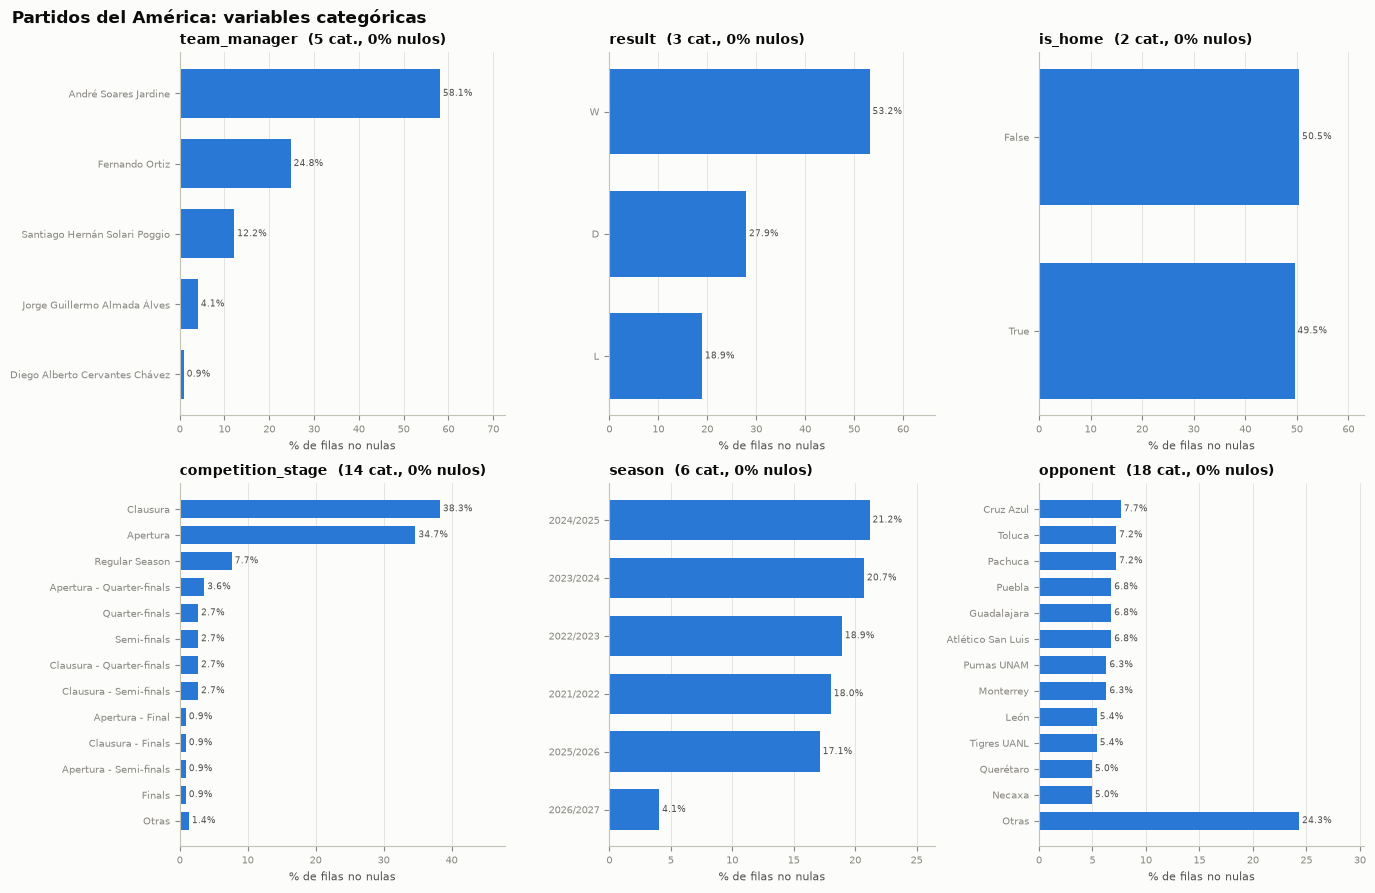

In [5]:
fig = eda.plot_categorical_grid(played, ["team_manager", "result", "is_home", "competition_stage", "season", "opponent"],
                                ncols=3, top=12, title="Partidos del América: variables categóricas")
save(fig, "matches_categoricas")

In [6]:
# Resultado por entrenador (% de partidos)
res = pd.crosstab(played.team_manager, played.result, normalize="index").mul(100).round(1)[["W", "D", "L"]]
res["partidos"] = played.team_manager.value_counts()
res["GF/p"] = played.groupby("team_manager").goals_for.mean().round(2)
res["GC/p"] = played.groupby("team_manager").goals_against.mean().round(2)
show(res.sort_values("partidos", ascending=False), "matches_resultado_por_entrenador")

result,W,D,L,partidos,GF/p,GC/p
team_manager,,,,,,
André Soares Jardine,52.700,27.900,19.400,129,1.720,0.920
Fernando Ortiz,58.200,25.500,16.400,55,2.050,1.070
Santiago Hernán Solari Poggio,40.700,33.300,25.900,27,1.150,1.000
Jorge Guillermo Almada Álves,66.700,22.200,11.100,9,2.330,1.110
Diego Alberto Cervantes Chávez,50.000,50.000,0.000,2,1.000,0.500


---
## 2. Eventos (`events`)
La tabla principal. Cada fila es una acción de cualquiera de los dos equipos. Hay 3 familias de columnas:
- **Generales** (aplican a todos los eventos): `type`, `team`, `player`, `position`, `minute`, `location`, `play_pattern`, `possession`, `under_pressure`, `obv_*`…
- **Específicas de un tipo** (`pass_*`, `shot_*`, `carry_*`, `duel_*`…): solo tienen valor en ese tipo de evento → se perfilan **condicionadas a su tipo**.
- **Anidadas** (`tactics`, `shot_freeze_frame`, `related_events`) y **coordenadas** (`location`, `*_end_location`) → se expanden a `x`, `y`.

In [7]:
events = eda.expand_xy(events)
ek = eda.classify_columns(events)
ek["aplica_a"] = ek.column.map(eda.column_type_owner).fillna("(todas)")
show(ek.kind.value_counts().to_frame("n_columnas"), "events_tipos_columnas")
show(ek.sort_values(["kind", "column"]).set_index("column"), "events_diccionario_columnas")

,n_columnas
kind,
boolean,60
numeric,47
categorical,36
id,12
coordinates,6
json,4
categorical_high,3
datetime,2


,kind,dtype,n_unique,pct_null,example,aplica_a
column,,,,,,
ball_recovery_offensive,boolean,object,1.000,99.990,True,Ball Recovery
ball_recovery_recovery_failure,boolean,object,1.000,99.810,True,Ball Recovery
block_deflection,boolean,object,1.000,99.970,True,Block
block_offensive,boolean,object,1.000,99.980,True,Block
block_save_block,boolean,object,1.000,99.990,True,Block
clearance_aerial_won,boolean,object,1.000,99.760,True,Clearance
clearance_head,boolean,object,1.000,99.360,True,Clearance
clearance_left_foot,boolean,object,1.000,99.810,True,Clearance
clearance_other,boolean,object,1.000,99.990,True,Clearance


### 2.1 ¿Qué columna vive en qué tipo de evento? (% de filas no nulas)

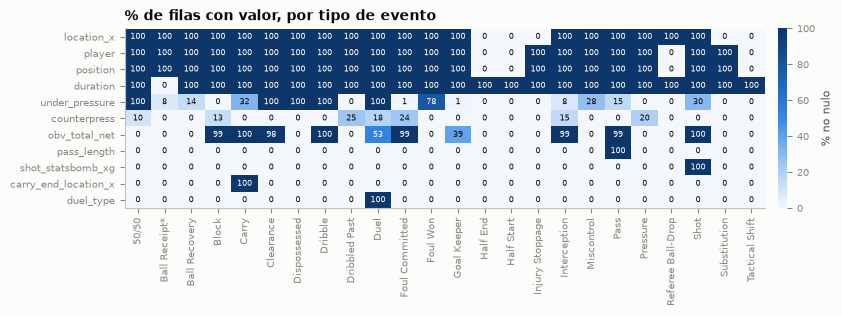

In [8]:
general = ["location_x", "player", "position", "duration", "under_pressure", "counterpress",
           "obv_total_net", "pass_length", "shot_statsbomb_xg", "carry_end_location_x", "duel_type"]
nm = eda.null_matrix_by_type(events, [c for c in general if c in events])
fig = eda.plot_heatmap(nm, "% de filas con valor, por tipo de evento", cmap=eda.SEQ,
                       vmin=0, vmax=100, fmt="{:.0f}", cbar_label="% no nulo", size=7)
save(fig, "events_nulos_por_tipo")

### 2.2 Variables categóricas generales

In [9]:
ev_cat = ["type", "play_pattern", "position", "period", "team", "possession_team", "location_bucket",
          "set_piece_phase", "attacking_direction"]
ev_cat = [c for c in ev_cat if c in events]
show(eda.profile_categorical(events, ev_cat), "events_categoricas_generales")

,count,pct_null,n_categories,mode,mode_pct,top_pct_cumulative,top_5
column,,,,,,,
type,736829,0.000,33,Pass,28.020,88.160,Pass (28.0%) | Ball Receipt* (25.7%) | Carry (...
play_pattern,736829,0.000,9,Regular Play,50.850,93.490,Regular Play (50.8%) | From Throw In (19.2%) |...
position,733114,0.500,24,Left Center Back,9.130,42.400,Left Center Back (9.1%) | Right Center Back (9...
period,736829,0.000,5,1,50.980,100.000,1 (51.0%) | 2 (48.9%) | 4 (0.1%) | 3 (0.0%) | ...
team,736829,0.000,19,América,53.400,67.460,América (53.4%) | Cruz Azul (3.9%) | Toluca (3...
possession_team,736829,0.000,19,América,54.350,68.240,América (54.4%) | Cruz Azul (3.8%) | Toluca (3...
location_bucket,729663,0.970,3,midfield_third,45.280,100.000,midfield_third (45.3%) | defensive_third (29.4...
set_piece_phase,57949,92.140,2,1.000,55.610,100.000,1.0 (55.6%) | 2.0 (44.4%)
attacking_direction,735249,0.210,2,right_to_left,50.350,100.000,right_to_left (50.3%) | left_to_right (49.7%)


In [10]:
show(eda.frequency_table(events.type), "events_frecuencia_type")

,count,pct,pct_cum
type,,,
Pass,206473,28.020,28.020
Ball Receipt*,189192,25.680,53.700
Carry,166915,22.650,76.350
Pressure,67072,9.100,85.450
Ball Recovery,19907,2.700,88.150
Duel,14192,1.930,90.080
Clearance,8399,1.140,91.220
Block,7569,1.030,92.250
Goal Keeper,6767,0.920,93.170


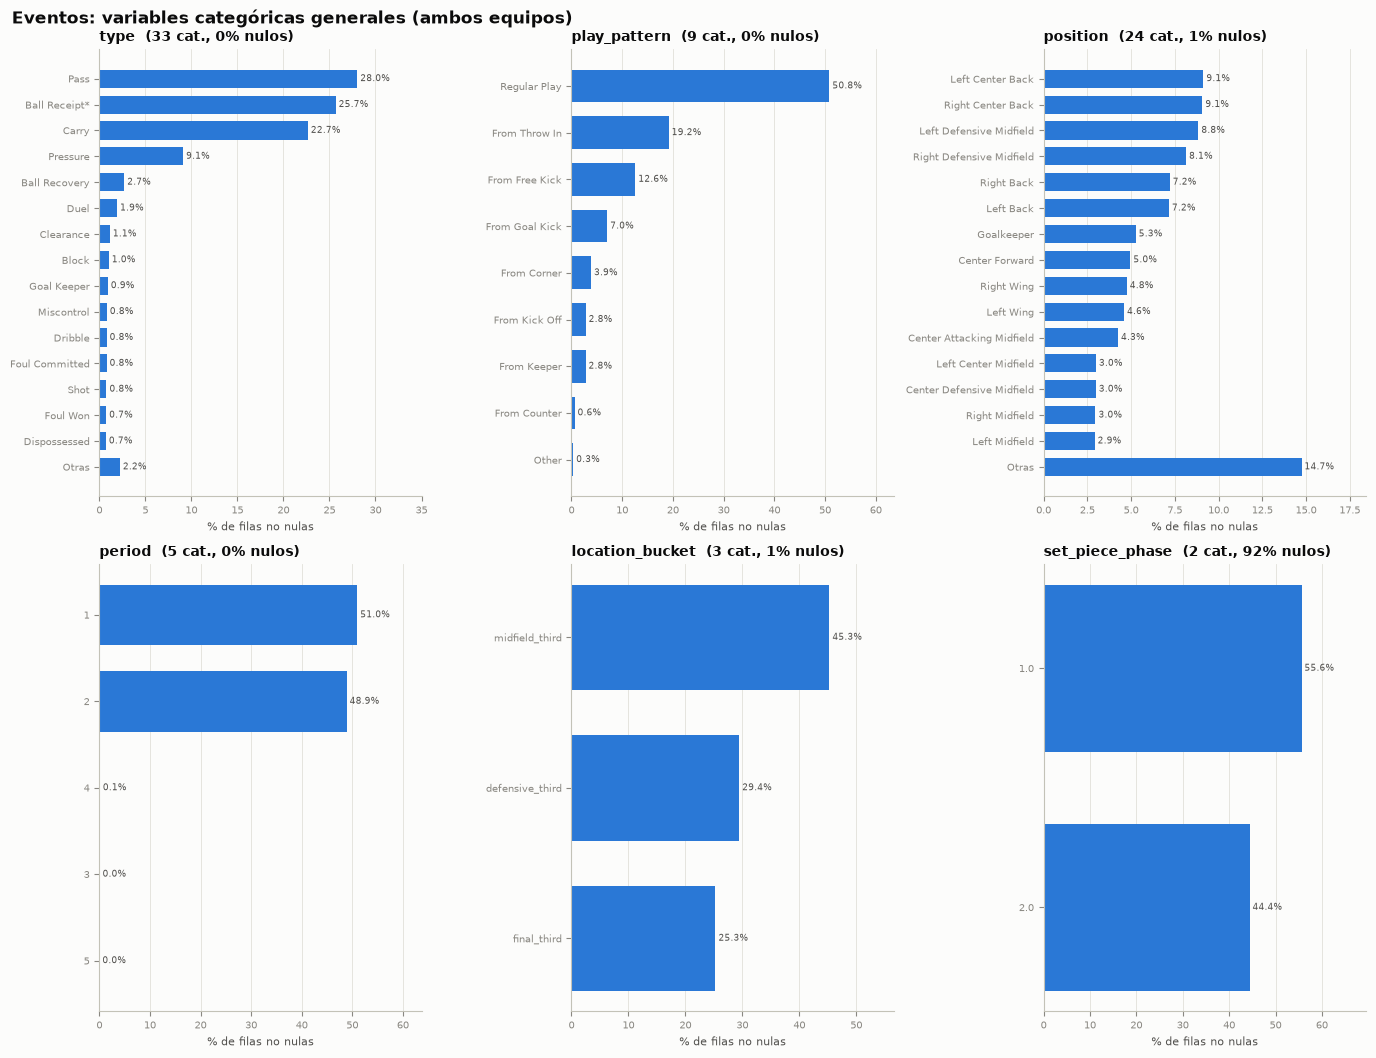

In [11]:
fig = eda.plot_categorical_grid(events, ["type", "play_pattern", "position", "period", "location_bucket", "set_piece_phase"],
                                ncols=3, top=15, title="Eventos: variables categóricas generales (ambos equipos)")
save(fig, "events_categoricas_generales")

### 2.3 Perfil condicionado al tipo de evento
Cada columna `pass_*` se describe solo sobre pases, `shot_*` solo sobre tiros, etc. Las generales, sobre todos los eventos.

In [12]:
prof = eda.profile_events_by_type(events, ek)
show(prof["numeric"].sort_values(["event_type", "column"]), "events_numericas")

,count,pct_null,n_unique,min,p5,p25,median,mean,p75,p95,max,std,mode,mode_pct,pct_zero,skew,event_type
column,,,,,,,,,,,,,,,,,
control_degree,624520,15.240,47068,0.000,0.000,0.676,1.000,0.789,1.000,1.000,1.000,0.354,1.000,68.410,10.390,-1.352,(todas)
duration,547611,25.680,53112,0.000,0.000,0.333,1.064,1.304,1.768,3.726,108.193,1.426,0.000,18.530,18.530,5.142,(todas)
goals_against,736829,0.000,5,0.000,0.000,0.000,1.000,0.955,2.000,3.000,4.000,0.989,0.000,39.850,39.850,0.909,(todas)
goals_for,736829,0.000,8,0.000,0.000,1.000,2.000,1.755,3.000,4.000,7.000,1.345,1.000,28.820,17.920,0.849,(todas)
location_x,729663,0.970,1201,0.000,9.600,36.200,57.200,57.916,80.300,105.800,120.000,28.863,120.000,0.290,0.000,0.012,(todas)
location_y,729663,0.970,800,0.100,4.600,19.600,39.400,39.516,59.300,75.400,80.000,22.989,80.000,0.770,0.000,0.035,(todas)
match_week,736829,0.000,25,1.000,2.000,6.000,11.000,11.258,16.000,23.000,25.000,6.666,10.000,5.210,0.000,0.253,(todas)
minute,736829,0.000,129,0.000,3.000,22.000,46.000,45.829,68.000,90.000,128.000,27.501,45.000,2.440,1.630,0.076,(todas)
obv_against_after,418788,43.160,80118,0.004,0.008,0.009,0.010,0.013,0.011,0.016,1.000,0.040,0.043,0.250,0.000,23.483,(todas)


In [13]:
show(prof["categorical"].sort_values(["event_type", "column"]), "events_categoricas_por_tipo")

,count,pct_null,n_categories,mode,mode_pct,top_pct_cumulative,top_5,event_type
column,,,,,,,,
attacking_direction,735249,0.210,2,right_to_left,50.350,100.000,right_to_left (50.3%) | left_to_right (49.7%),(todas)
location_bucket,729663,0.970,3,midfield_third,45.280,100.000,midfield_third (45.3%) | defensive_third (29.4...,(todas)
opponent,736829,0.000,18,Cruz Azul,7.720,35.970,Cruz Azul (7.7%) | Pachuca (7.3%) | Toluca (7....,(todas)
play_pattern,736829,0.000,9,Regular Play,50.850,93.490,Regular Play (50.8%) | From Throw In (19.2%) |...,(todas)
player,733114,0.500,906,Álvaro Fidalgo Fernández,5.290,16.440,Álvaro Fidalgo Fernández (5.3%) | Alejandro Ze...,(todas)
position,733114,0.500,24,Left Center Back,9.130,42.400,Left Center Back (9.1%) | Right Center Back (9...,(todas)
possession_team,736829,0.000,19,América,54.350,68.240,América (54.4%) | Cruz Azul (3.8%) | Toluca (3...,(todas)
result,736829,0.000,3,W,53.300,100.000,W (53.3%) | D (28.0%) | L (18.7%),(todas)
season,736829,0.000,6,2023/2024,22.530,96.070,2023/2024 (22.5%) | 2024/2025 (21.6%) | 2022/2...,(todas)


In [14]:
# Flags: % True dentro de su tipo de evento (NaN = False)
show(prof["boolean"].sort_values(["event_type", "pct_true"], ascending=[True, False]), "events_booleanas")

,rows,n_true,n_false_explicit,n_null,pct_true,event_type
column,,,,,,
is_controlled_possession,736829,524248,100272,112309,71.150,(todas)
is_home,736829,367612,369217,0,49.890,(todas)
is_transition,736829,197314,427206,112309,26.780,(todas)
under_pressure,736829,144843,0,591986,19.660,(todas)
counterpress,736829,20014,0,716815,2.720,(todas)
off_camera,736829,10308,0,726521,1.400,(todas)
out,736829,10066,0,726763,1.370,(todas)
half_start_late_video_start,736829,4,0,736825,0.000,(todas)
player_off_permanent,736829,1,0,736828,0.000,(todas)


### 2.4 Distribuciones numéricas

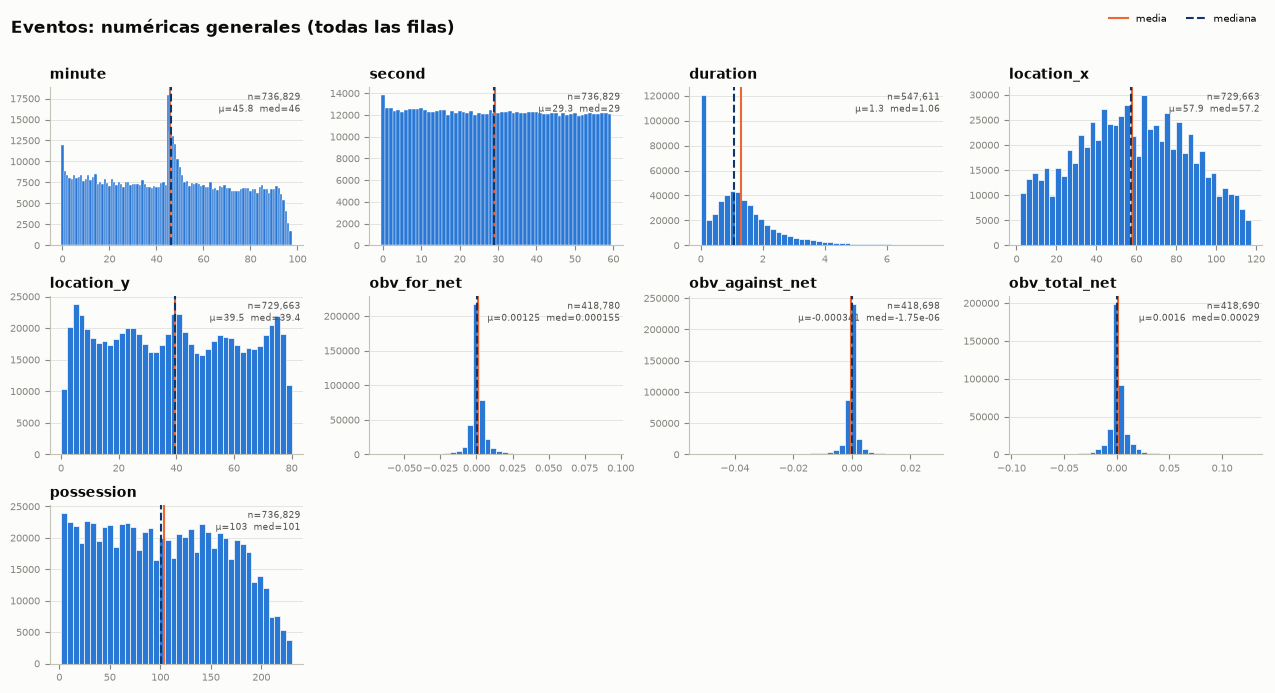

In [15]:
gen_num = ["minute", "second", "duration", "location_x", "location_y", "obv_for_net", "obv_against_net",
           "obv_total_net", "possession"]
fig = eda.plot_numeric_grid(events, gen_num, title="Eventos: numéricas generales (todas las filas)")
save(fig, "events_numericas_generales")

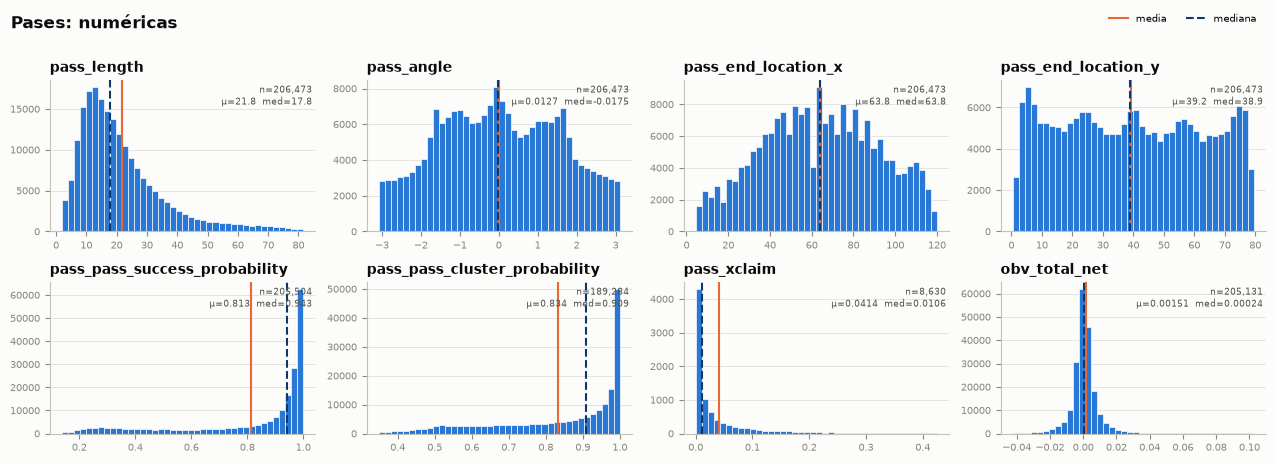

In [16]:
passes = events[events.type == "Pass"]
pass_num = ["pass_length", "pass_angle", "pass_end_location_x", "pass_end_location_y",
            "pass_pass_success_probability", "pass_pass_cluster_probability", "pass_xclaim", "obv_total_net"]
fig = eda.plot_numeric_grid(passes, [c for c in pass_num if c in passes], title="Pases: numéricas")
save(fig, "events_pases_numericas")

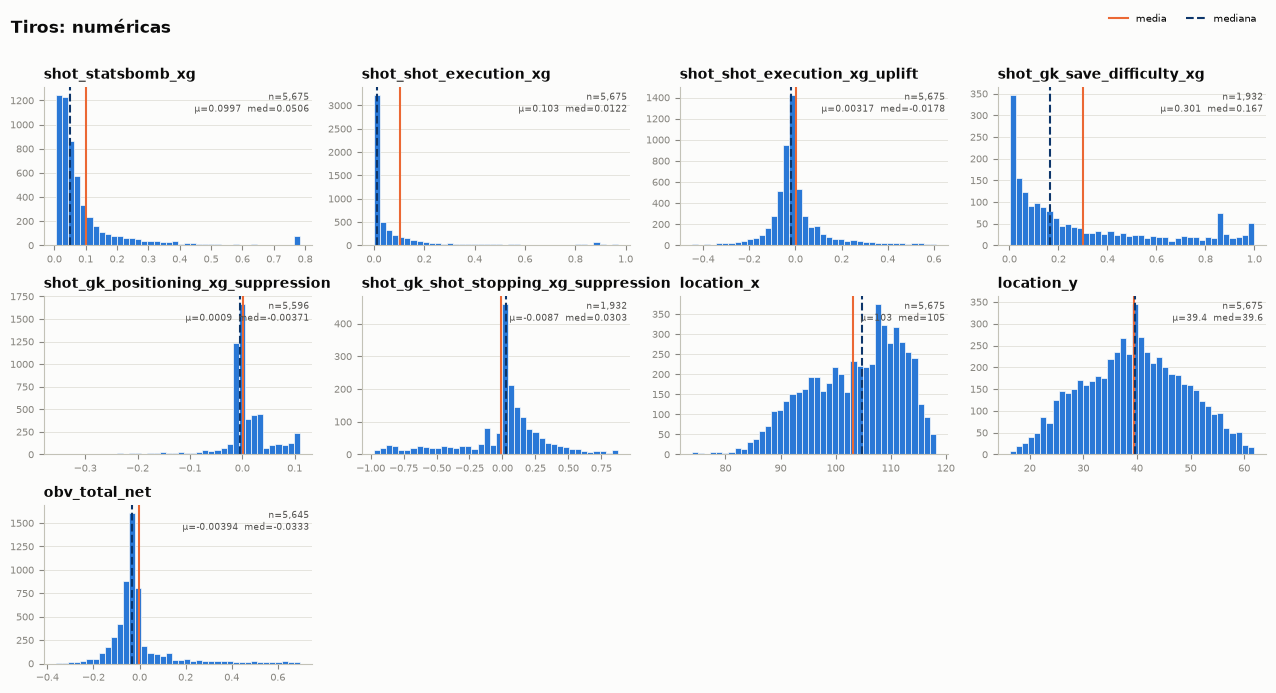

In [17]:
shots = events[events.type == "Shot"]
shot_num = ["shot_statsbomb_xg", "shot_shot_execution_xg", "shot_shot_execution_xg_uplift",
            "shot_gk_save_difficulty_xg", "shot_gk_positioning_xg_suppression",
            "shot_gk_shot_stopping_xg_suppression", "location_x", "location_y", "obv_total_net"]
fig = eda.plot_numeric_grid(shots, [c for c in shot_num if c in shots], title="Tiros: numéricas")
save(fig, "events_tiros_numericas")

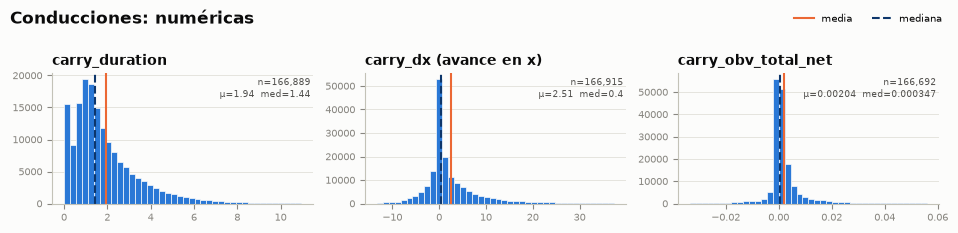

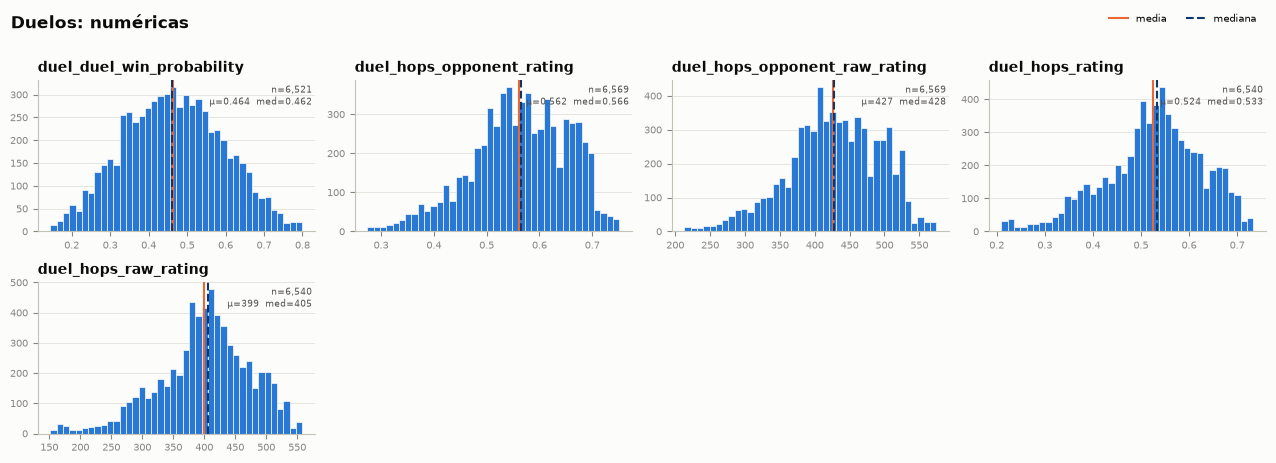

In [18]:
carries = events[events.type == "Carry"]
cd = pd.DataFrame({"carry_duration": carries.duration,
                   "carry_dx (avance en x)": carries.carry_end_location_x - carries.location_x,
                   "carry_obv_total_net": carries.obv_total_net})
fig = eda.plot_numeric_grid(cd, list(cd.columns), ncols=3, title="Conducciones: numéricas")
save(fig, "events_conducciones_numericas")
duels = events[events.type == "Duel"]
duel_num = [c for c in duels if c.startswith("duel_") and pd.api.types.is_numeric_dtype(duels[c])]
if duel_num:
    fig = eda.plot_numeric_grid(duels, duel_num, ncols=4, title="Duelos: numéricas")
    save(fig, "events_duelos_numericas")

### 2.5 Categóricas por tipo de evento

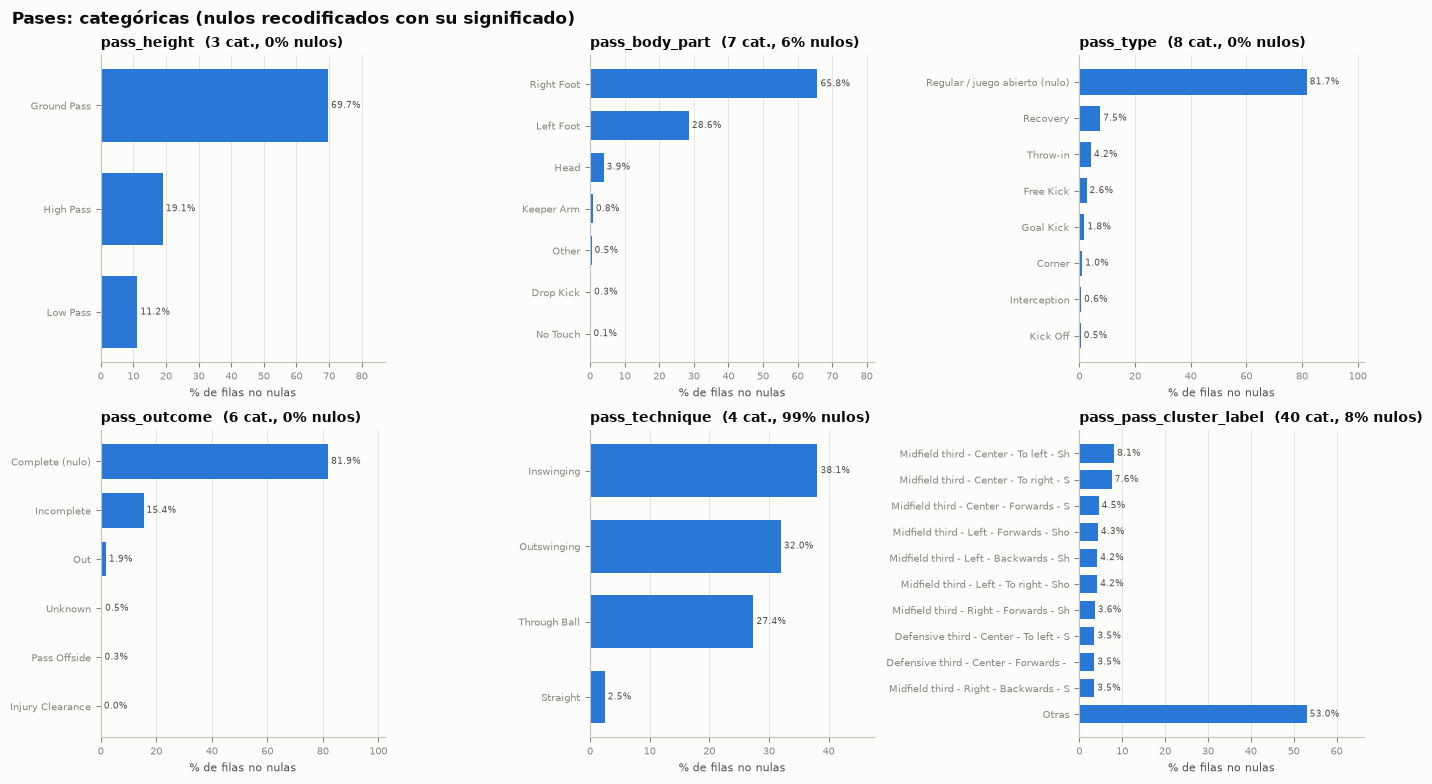

In [19]:
passes_lbl = passes.assign(pass_outcome=passes.pass_outcome.fillna("Complete (nulo)"),
                            pass_type=passes.pass_type.fillna("Regular / juego abierto (nulo)"))
fig = eda.plot_categorical_grid(passes_lbl, ["pass_height", "pass_body_part", "pass_type", "pass_outcome",
                                          "pass_technique", "pass_pass_cluster_label"], ncols=3, top=10,
                                title="Pases: categóricas (nulos recodificados con su significado)")
save(fig, "events_pases_categoricas")

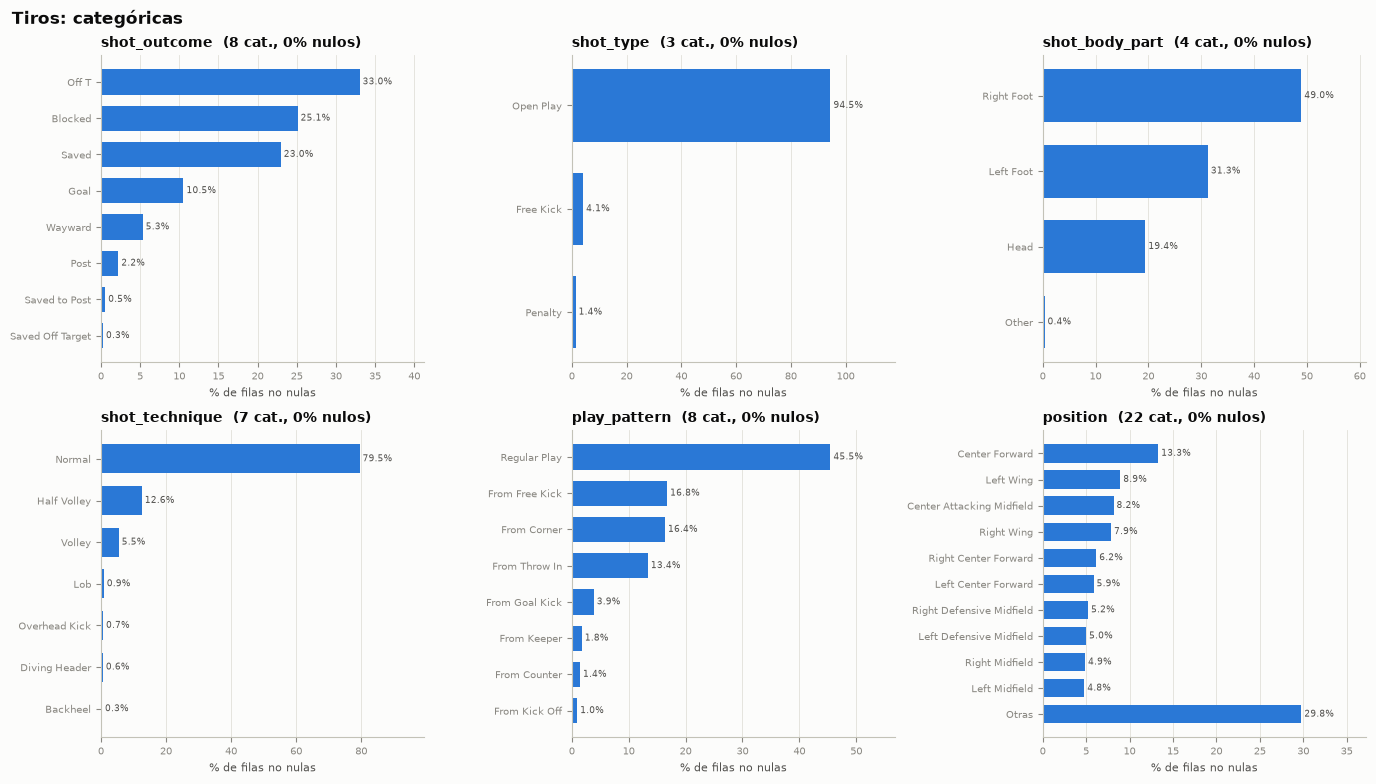

In [20]:
fig = eda.plot_categorical_grid(shots, ["shot_outcome", "shot_type", "shot_body_part", "shot_technique", "play_pattern", "position"],
                                ncols=3, top=10, title="Tiros: categóricas")
save(fig, "events_tiros_categoricas")

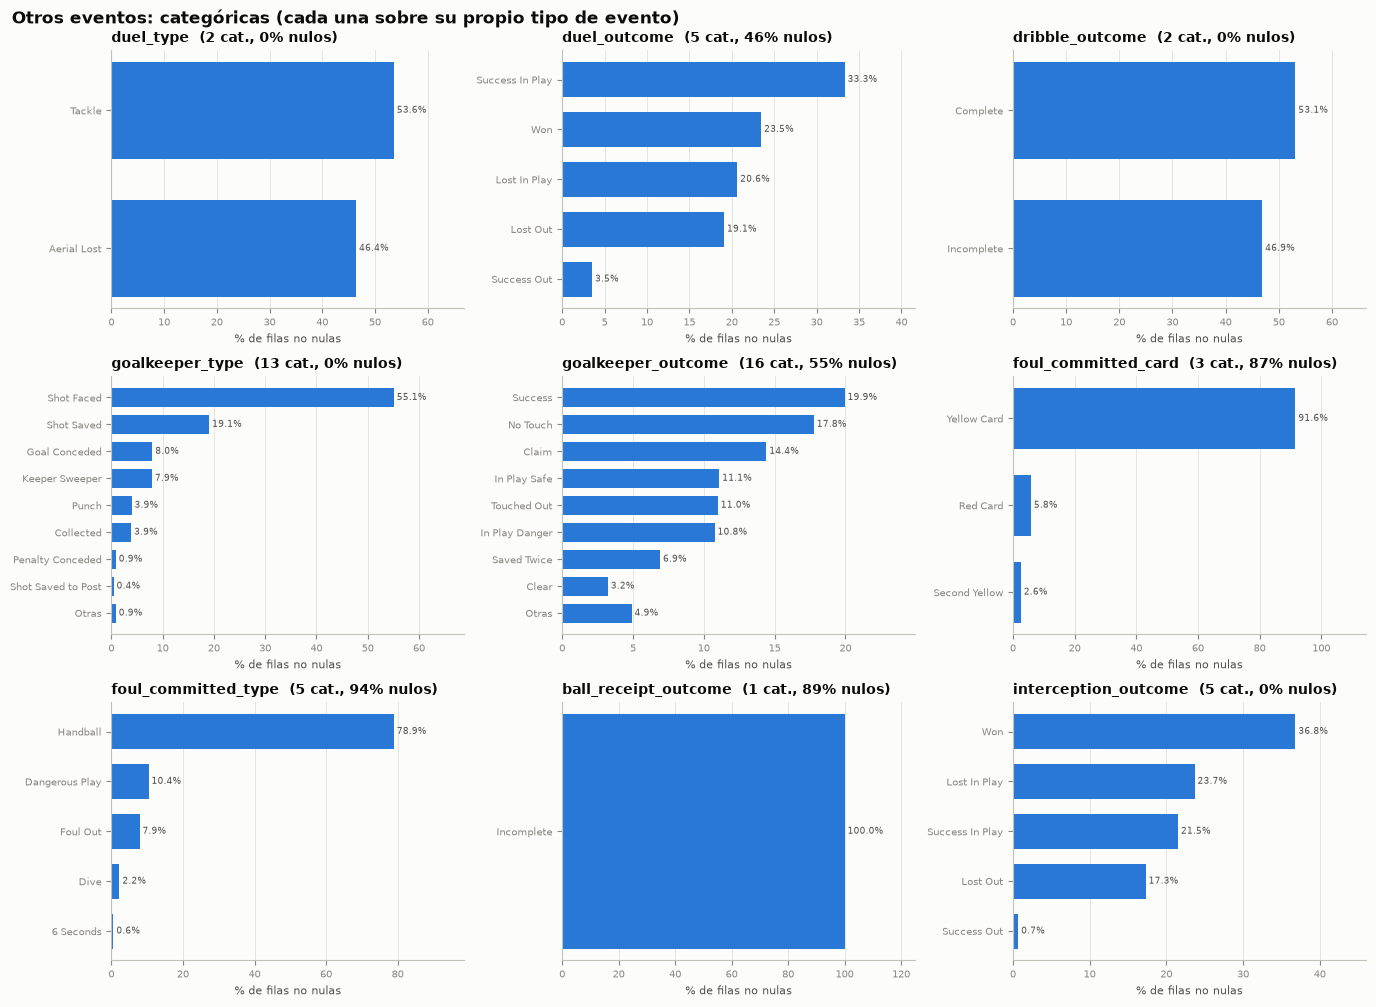

In [21]:
other = {"Duel": ["duel_type", "duel_outcome"], "Dribble": ["dribble_outcome"], "Goal Keeper": ["goalkeeper_type", "goalkeeper_outcome"],
         "Foul Committed": ["foul_committed_card", "foul_committed_type"], "Ball Receipt*": ["ball_receipt_outcome"],
         "Interception": ["interception_outcome"]}
per_col = {c: events[events.type == t] for t, cols in other.items() for c in cols}
fig = eda.plot_categorical_grid(per_col, list(per_col), ncols=3, top=8,
                                title="Otros eventos: categóricas (cada una sobre su propio tipo de evento)")
save(fig, "events_otros_categoricas")

### 2.6 Dónde ocurren los eventos (coordenadas)
Cancha StatsBomb 120×80; cada equipo ataca de izquierda a derecha.

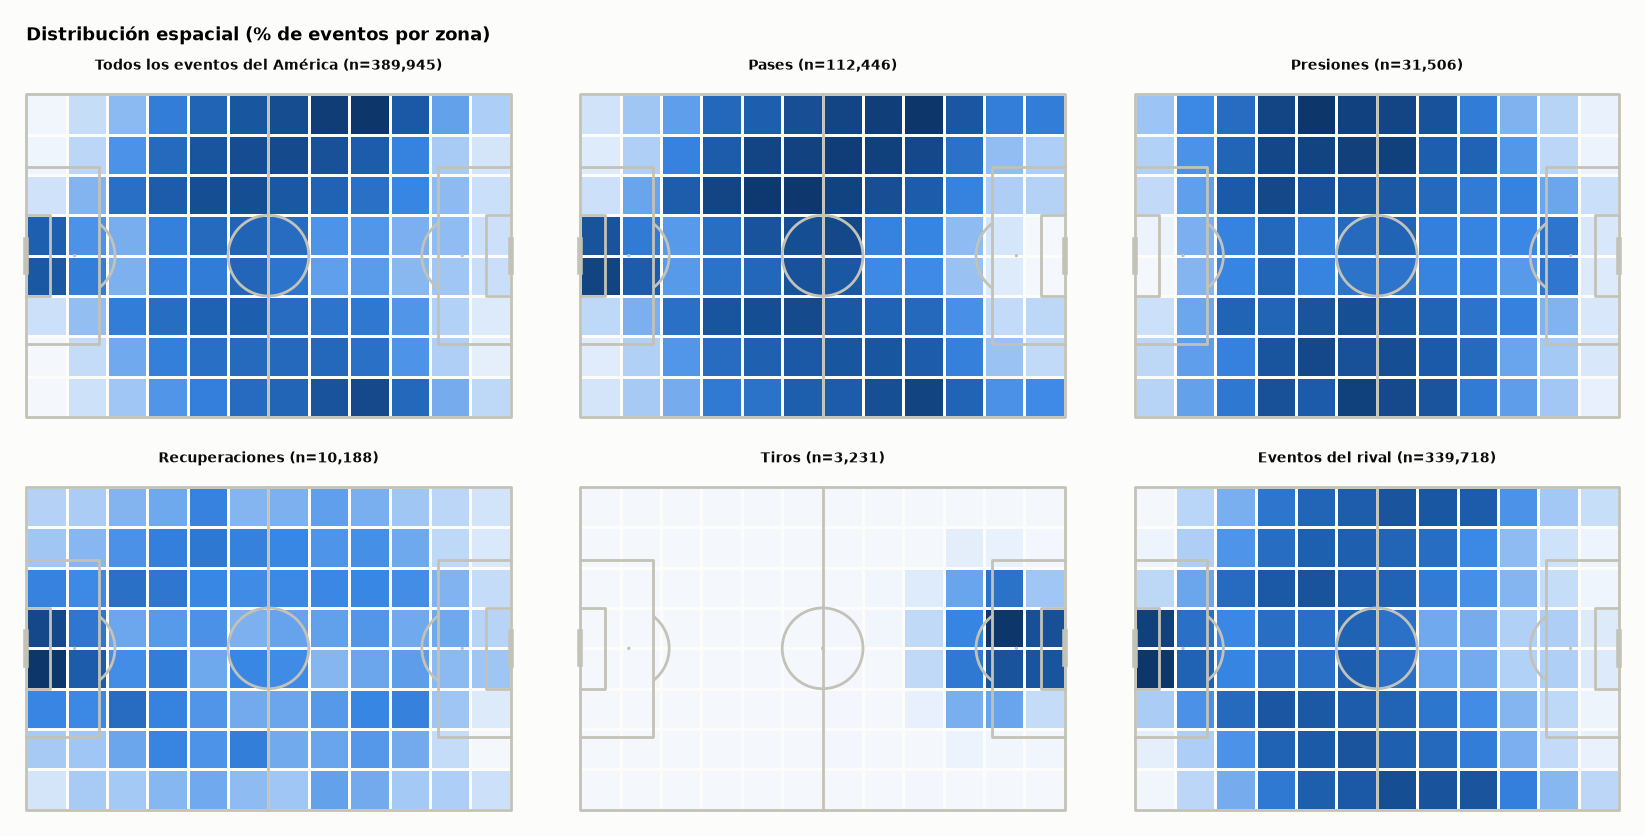

In [22]:
pitch = Pitch(pitch_type="statsbomb", line_color=eda.AXIS, pitch_color=eda.SURFACE, line_zorder=2)
fig, axs = pitch.grid(nrows=2, ncols=3, figheight=8.5, title_height=0.06, endnote_height=0, axis=False, grid_height=0.88, title_space=0.02)
am = events[events.team == TEAM]
panels = [("Todos los eventos del América", am), ("Pases", am[am.type == "Pass"]),
          ("Presiones", am[am.type == "Pressure"]), ("Recuperaciones", am[am.type == "Ball Recovery"]),
          ("Tiros", am[am.type == "Shot"]), ("Eventos del rival", events[events.team != TEAM])]
for ax, (t, d) in zip(axs["pitch"].flat, panels):
    d = d.dropna(subset=["location_x", "location_y"])
    st = pitch.bin_statistic(d.location_x, d.location_y, statistic="count", bins=(12, 8), normalize=True)
    pitch.heatmap(st, ax=ax, cmap=eda.SEQ, edgecolor=eda.SURFACE)
    ax.set_title(f"{t} (n={len(d):,})", fontsize=10)
axs["title"].text(0, 0.5, "Distribución espacial (% de eventos por zona)", fontsize=13, fontweight="bold", va="center")
save(fig, "events_mapas_calor")

### 2.7 Correlaciones numéricas (Spearman)
Spearman (rangos) porque la mayoría de las variables son asimétricas (xG, OBV, longitudes).

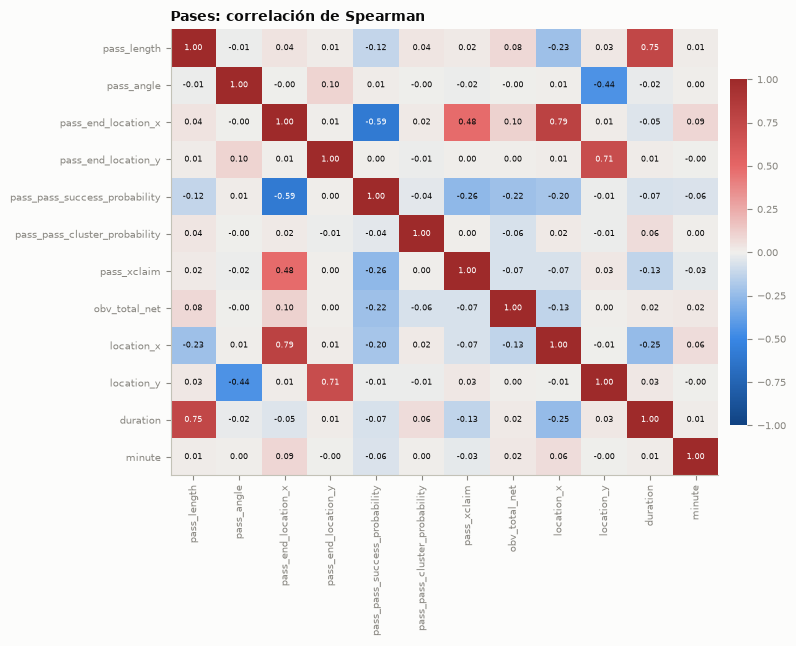

,var_1,var_2,r
0,pass_end_location_x,location_x,0.790
1,pass_length,duration,0.750
2,pass_end_location_y,location_y,0.705
3,pass_end_location_x,pass_pass_success_probability,-0.591
4,pass_end_location_x,pass_xclaim,0.477
5,pass_angle,location_y,-0.443
6,pass_pass_success_probability,pass_xclaim,-0.265
7,location_x,duration,-0.249
8,pass_length,location_x,-0.226
9,pass_pass_success_probability,obv_total_net,-0.221


In [23]:
pc = eda.correlation(passes, [c for c in pass_num + ["location_x", "location_y", "duration", "minute"] if c in passes])
fig = eda.plot_heatmap(pc, "Pases: correlación de Spearman", size=6.5)
save(fig, "events_pases_correlacion")
show(eda.top_correlations(pc, 10), "events_pases_top_correlaciones")

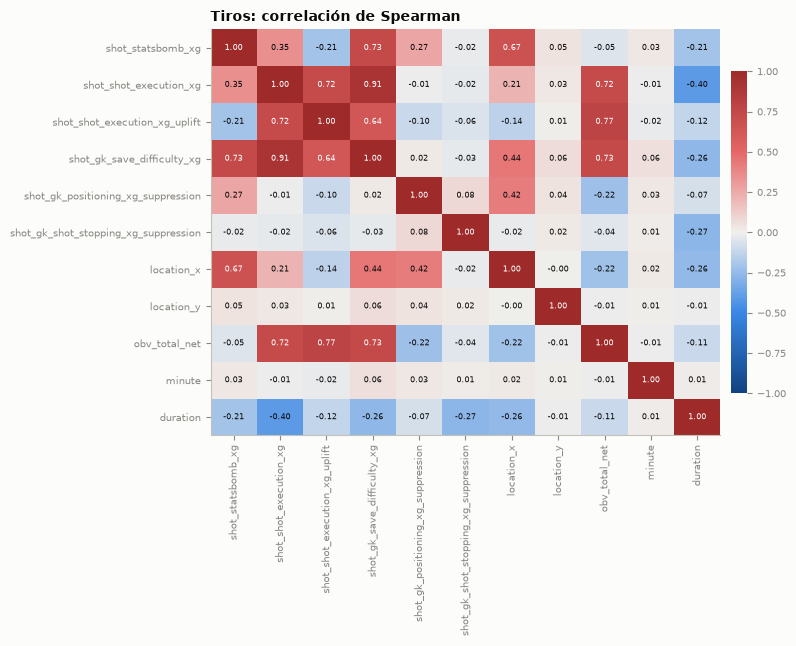

,var_1,var_2,r
0,shot_shot_execution_xg,shot_gk_save_difficulty_xg,0.907
1,shot_shot_execution_xg_uplift,obv_total_net,0.774
2,shot_gk_save_difficulty_xg,obv_total_net,0.734
3,shot_statsbomb_xg,shot_gk_save_difficulty_xg,0.729
4,shot_shot_execution_xg,obv_total_net,0.724
5,shot_shot_execution_xg,shot_shot_execution_xg_uplift,0.721
6,shot_statsbomb_xg,location_x,0.673
7,shot_shot_execution_xg_uplift,shot_gk_save_difficulty_xg,0.640
8,shot_gk_save_difficulty_xg,location_x,0.438
9,shot_gk_positioning_xg_suppression,location_x,0.418


In [24]:
sc = eda.correlation(shots, [c for c in shot_num + ["minute", "duration"] if c in shots])
fig = eda.plot_heatmap(sc, "Tiros: correlación de Spearman", size=6.5)
save(fig, "events_tiros_correlacion")
show(eda.top_correlations(sc, 10), "events_tiros_top_correlaciones")

### 2.8 Asociación entre categóricas (V de Cramér)

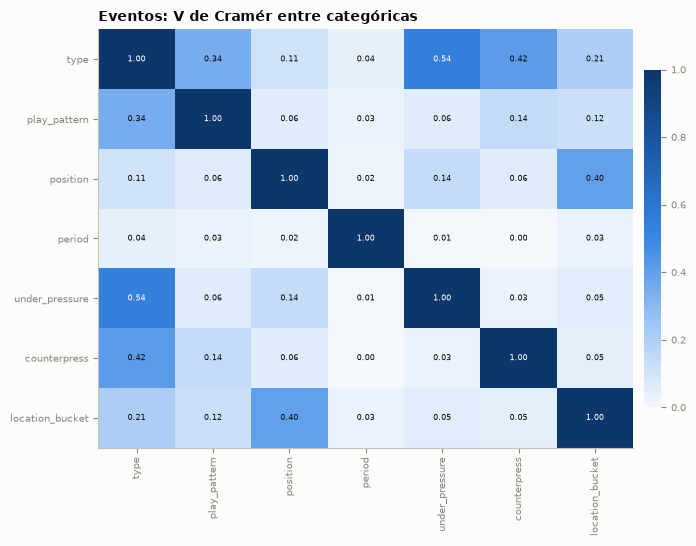

In [25]:
cv_cols = ["type", "play_pattern", "position", "period", "under_pressure", "counterpress", "location_bucket"]
cv_cols = [c for c in cv_cols if c in events]
tmp = events[cv_cols].copy()
for c in ["under_pressure", "counterpress"]:
    tmp[c] = tmp[c].fillna(False).astype(bool)
cv = eda.cramers_v_matrix(tmp.sample(min(len(tmp), 300_000), random_state=0), cv_cols)
fig = eda.plot_heatmap(cv, "Eventos: V de Cramér entre categóricas", cmap=eda.SEQ, vmin=0, vmax=1, size=5.5)
save(fig, "events_cramers_v")

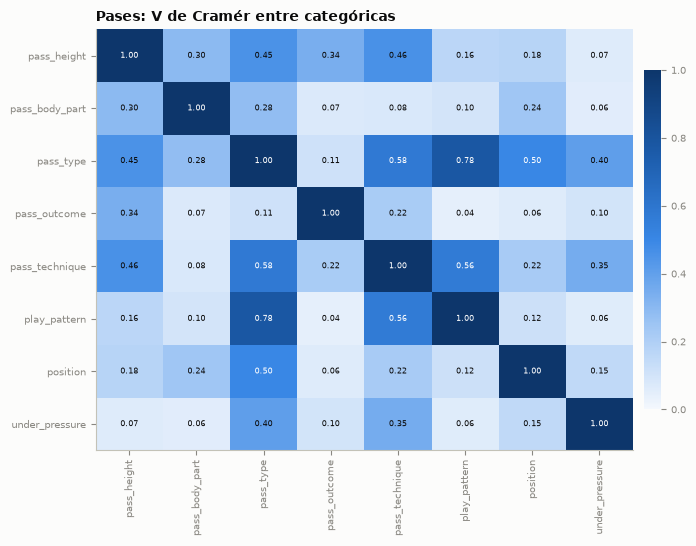

In [26]:
pcv_cols = ["pass_height", "pass_body_part", "pass_type", "pass_outcome", "pass_technique", "play_pattern", "position", "under_pressure"]
tmp = passes[pcv_cols].copy()
tmp["pass_outcome"] = tmp.pass_outcome.fillna("Complete")
tmp["under_pressure"] = tmp.under_pressure.fillna(False).astype(bool)
cv = eda.cramers_v_matrix(tmp, pcv_cols)
fig = eda.plot_heatmap(cv, "Pases: V de Cramér entre categóricas", cmap=eda.SEQ, vmin=0, vmax=1, size=5.5)
save(fig, "events_pases_cramers_v")

### 2.9 Posesiones: la unidad del marco analítico

,count,pct_null,n_unique,min,p5,p25,median,mean,p75,p95,max,std,mode,mode_pct,pct_zero,skew
column,,,,,,,,,,,,,,,,
n_events,47033,0.000,143,1.000,2.000,5.000,10.000,15.666,20.000,47.000,212.000,15.559,5.000,7.780,0.000,2.464
n_passes,47033,0.000,53,0.000,0.000,1.000,3.000,4.390,6.000,14.000,64.000,4.817,1.000,22.140,7.590,2.514
start_x,46371,1.410,1185,0.100,6.000,19.800,44.100,48.284,69.700,114.000,120.000,32.769,120.000,4.610,0.000,0.523
max_x,46371,1.410,1178,1.300,42.850,77.700,94.200,90.131,108.100,118.700,120.000,23.527,120.000,4.630,0.000,-1.282
dur_s,47033,0.000,31432,0.000,1.168,4.216,9.571,15.186,20.400,48.258,184.963,16.308,0.000,2.080,2.080,2.321
xg,47033,0.000,5171,0.000,0.000,0.000,0.000,0.012,0.000,0.060,1.517,0.063,0.000,88.840,88.840,9.462


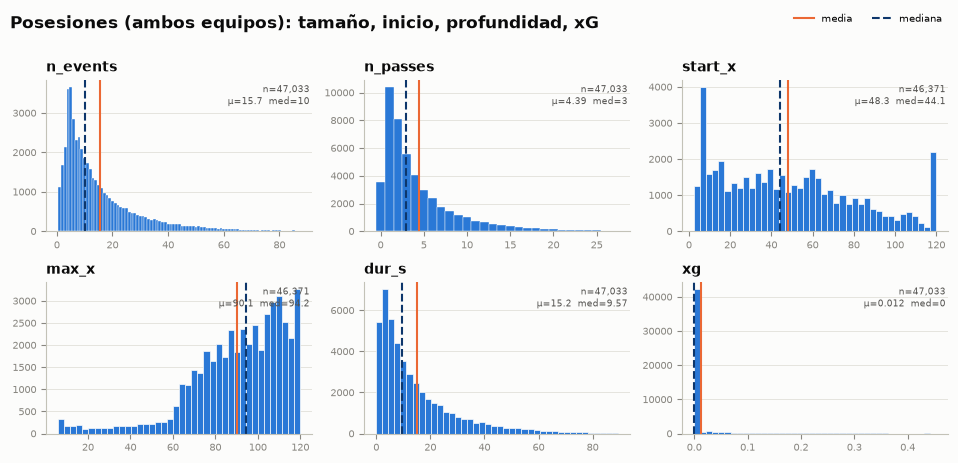

Posesiones: 47,033 | por partido: 212 | % que terminan en tiro: 11.2%


In [27]:
poss = (events.groupby(["match_id", "possession"])
        .agg(team=("possession_team", "first"), play_pattern=("play_pattern", "first"),
             n_events=("id", "size"), n_passes=("type", lambda t: (t == "Pass").sum()),
             start_x=("location_x", "first"), max_x=("location_x", "max"),
             dur_s=("duration", "sum"), shot=("type", lambda t: (t == "Shot").any()),
             xg=("shot_statsbomb_xg", "sum")))
show(eda.profile_numeric(poss, ["n_events", "n_passes", "start_x", "max_x", "dur_s", "xg"]), "posesiones_numericas")
fig = eda.plot_numeric_grid(poss, ["n_events", "n_passes", "start_x", "max_x", "dur_s", "xg"], ncols=3,
                            title="Posesiones (ambos equipos): tamaño, inicio, profundidad, xG")
save(fig, "posesiones_numericas")
print(f"Posesiones: {len(poss):,} | por partido: {len(poss) / events.match_id.nunique():.0f} | "
      f"% que terminan en tiro: {100 * poss.shot.mean():.1f}%")

---
## 3. Métricas por equipo y partido (`team_match_stats`)
~200 métricas agregadas por StatsBomb (xG, PPDA, OBV, presiones, balón parado…). Se perfilan **solo las filas del América** (una por partido); las del rival están en las columnas `*_conceded`.

In [28]:
ts = team_stats[team_stats.team_name == TEAM].copy()
ts.columns = [c.replace("team_match_", "") for c in ts.columns]
tk = eda.classify_columns(ts)
show(tk.kind.value_counts().to_frame("n_columnas"), "team_tipos_columnas")
# passing_ratio de la API es idéntica a opp_final_third_pass_ratio (ver sección 7) -> precisión real:
ts["pass_completion"] = ts.successful_passes / ts.passes
ts_num = eda.cols_of(eda.classify_columns(ts), "numeric")
ts_prof = eda.profile_numeric(ts, ts_num)
show(ts_prof, "team_numericas")

,n_columnas
kind,
numeric,199
categorical,8
id,6
boolean,2
datetime,1


,count,pct_null,n_unique,min,p5,p25,median,mean,p75,p95,max,std,mode,mode_pct,pct_zero,skew
column,,,,,,,,,,,,,,,,
gd,221,0.000,12,-4.000,-2.000,0.000,1.000,0.765,2.000,4.000,7.000,1.692,0.000,28.050,28.050,0.420
xgd,221,0.000,221,-1.828,-1.055,-0.082,0.607,0.601,1.206,2.361,4.312,1.041,2.164,0.450,0.000,0.415
np_shots,221,0.000,27,3.000,6.000,11.000,14.000,14.303,17.000,24.000,32.000,5.404,16.000,9.050,0.000,0.367
op_shots,221,0.000,21,2.000,5.000,7.000,11.000,10.733,13.000,18.000,25.000,4.364,7.000,9.500,0.000,0.499
op_shots_outside_box,221,0.000,15,0.000,1.000,2.000,4.000,4.466,6.000,9.000,16.000,2.704,4.000,15.840,3.170,0.998
sp_shots,221,0.000,11,0.000,1.000,2.000,4.000,3.923,5.000,8.000,10.000,2.406,4.000,16.290,2.710,0.666
np_xg,221,0.000,221,0.089,0.383,0.890,1.236,1.366,1.759,2.627,4.185,0.738,2.164,0.450,0.000,1.142
op_xg,221,0.000,221,0.033,0.264,0.649,0.999,1.087,1.384,2.250,4.008,0.667,1.402,0.450,0.000,1.421
sp_xg,221,0.000,216,0.000,0.021,0.115,0.244,0.302,0.416,0.803,1.207,0.256,0.000,2.710,2.710,1.318


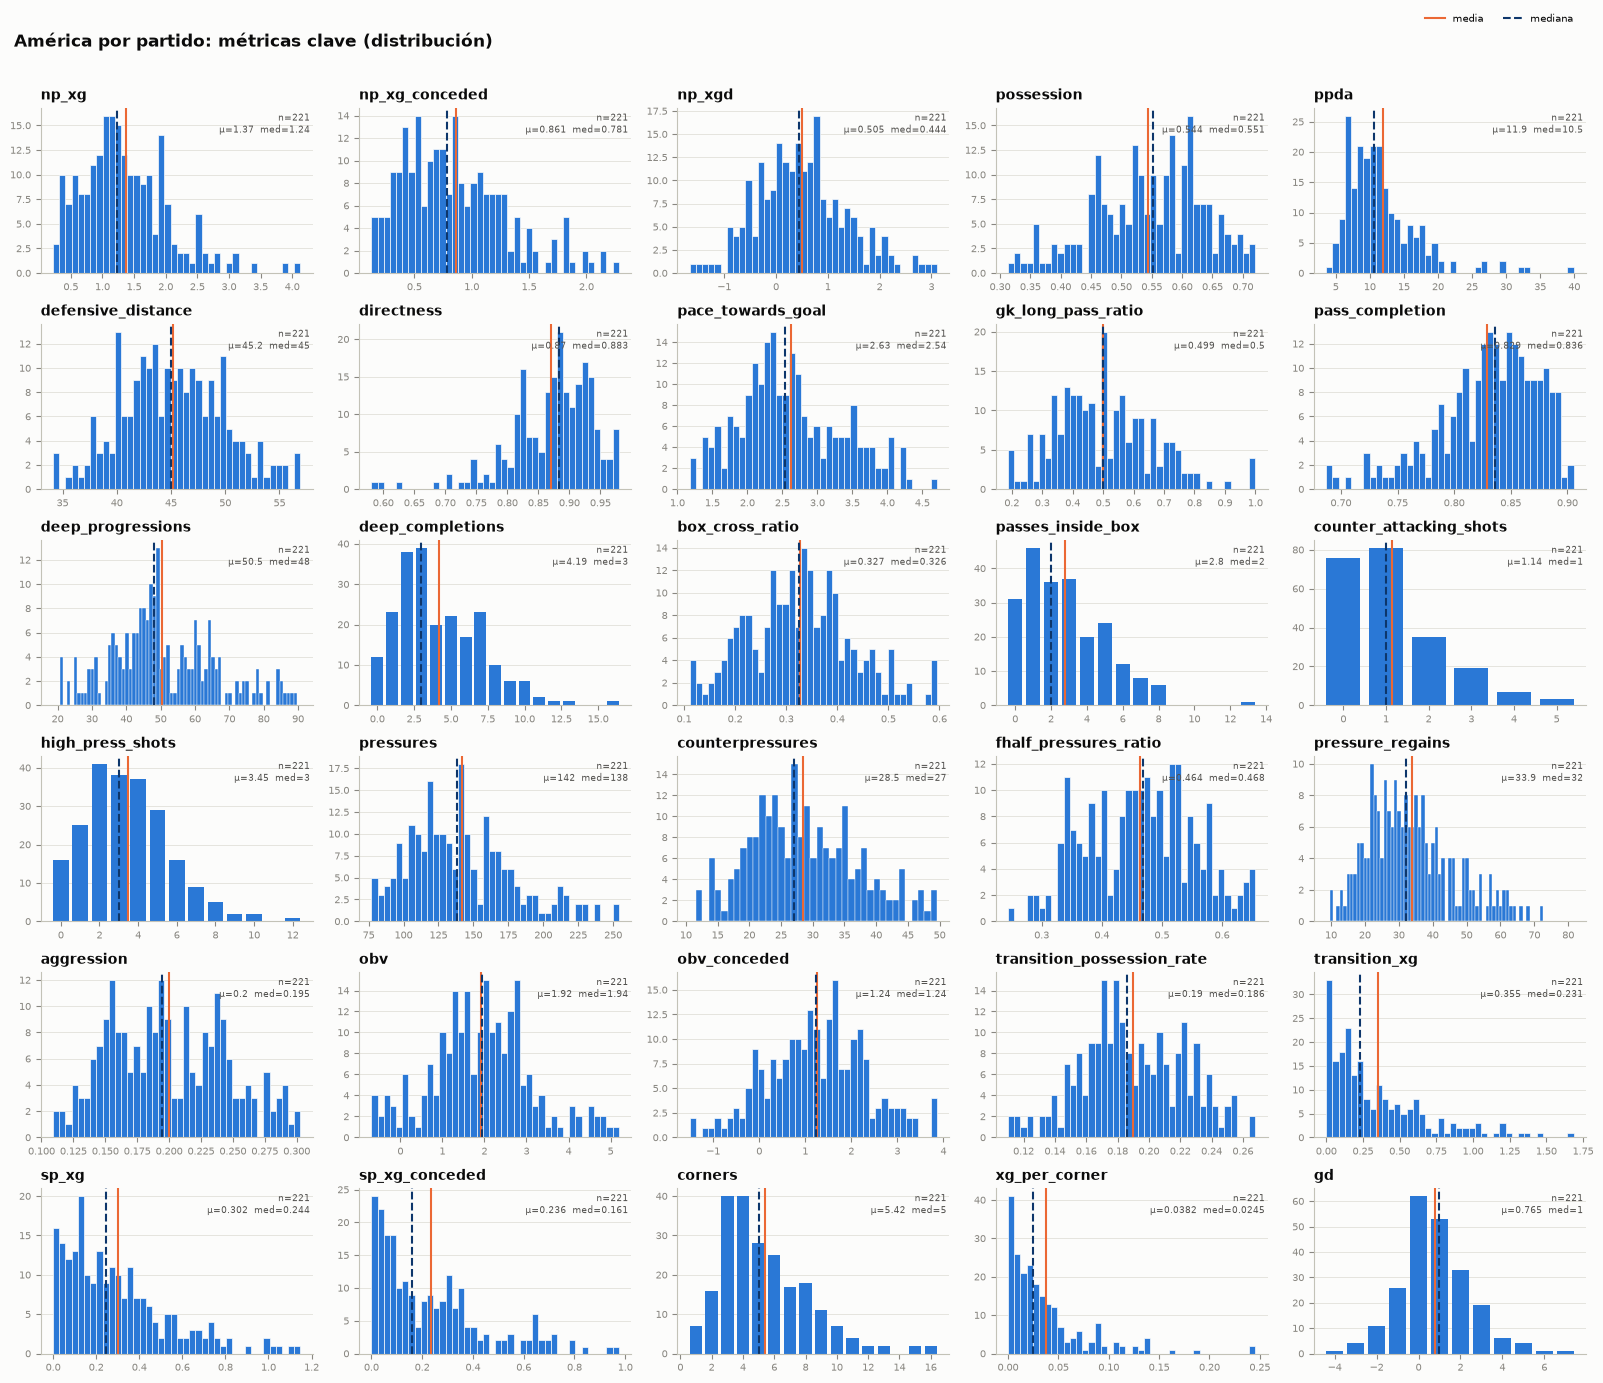

In [29]:
# Métricas clave del reto
KEY = ["np_xg", "np_xg_conceded", "np_xgd", "possession", "ppda", "defensive_distance", "directness",
       "pace_towards_goal", "gk_long_pass_ratio", "pass_completion", "deep_progressions", "deep_completions",
       "box_cross_ratio", "passes_inside_box", "counter_attacking_shots", "high_press_shots",
       "pressures", "counterpressures", "fhalf_pressures_ratio", "pressure_regains", "aggression",
       "obv", "obv_conceded", "transition_possession_rate", "transition_xg", "sp_xg", "sp_xg_conceded",
       "corners", "xg_per_corner", "gd"]
KEY = [c for c in KEY if c in ts]
fig = eda.plot_numeric_grid(ts, KEY, ncols=5, title="América por partido: métricas clave (distribución)")
save(fig, "team_numericas_clave")

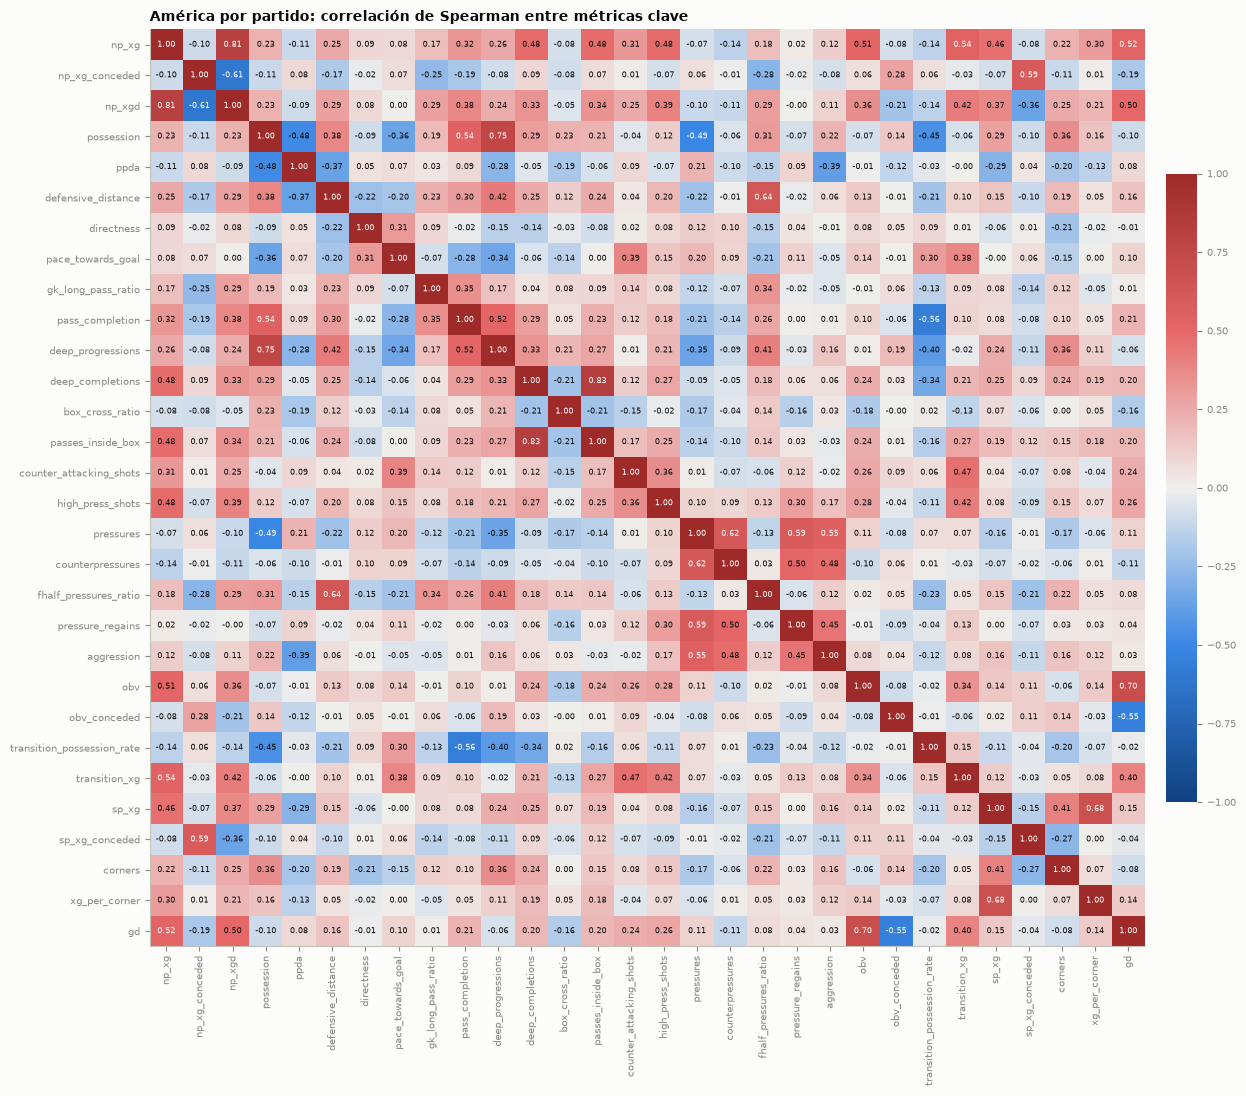

In [30]:
tc = eda.correlation(ts, KEY)
fig = eda.plot_heatmap(tc, "América por partido: correlación de Spearman entre métricas clave", size=11)
save(fig, "team_correlacion_clave")

In [31]:
# Todas las ~200 métricas: pares con correlación más fuerte (muchos son redundantes por construcción)
tc_all = eda.correlation(ts, ts_num)
show(eda.top_correlations(tc_all, 40), "team_top_correlaciones")

,var_1,var_2,r
0,opp_final_third_pass_ratio,passing_ratio,1.000
1,goals_from_throw_ins_conceded,throw_in_goal_ratio_conceded,1.000
2,goals_conceded,goals_against,1.000
3,goals_from_throw_ins,throw_in_goal_ratio,1.000
4,direct_free_kick_goals_conceded,direct_free_kick_goal_ratio_conceded,1.000
5,throw_in_xg,xg_per_throw_in,1.000
6,throw_in_xg_conceded,xg_per_throw_in_conceded,0.999
7,goals_from_indirect_free_kicks,indirect_free_kick_goal_ratio,0.999
8,goals_from_indirect_free_kicks_conceded,indirect_free_kick_goal_ratio_conceded,0.999
9,goals_from_free_kicks_conceded,free_kick_goal_ratio_conceded,0.999


In [32]:
# ¿Qué métricas se relacionan más con el resultado (diferencia de goles)?
with_gd = tc_all["gd"].drop(["gd", "np_gd", "goals", "goals_conceded", "own_goals", "opposition_own_goals"], errors="ignore")
show(with_gd.reindex(with_gd.abs().sort_values(ascending=False).index).head(25).to_frame("spearman_con_gd"), "team_correlacion_con_gd")

,spearman_con_gd
goals_for,0.769
obv,0.697
goals_against,-0.604
obv_conceded,-0.545
xgd,0.539
op_xg,0.538
np_xg,0.517
np_xgd,0.497
obv_shot,0.462
np_xg_per_shot,0.439


In [33]:
# Métricas por entrenador (media) — primera mirada a diferencias de estilo
by_mgr = ts.merge(ctx[["match_id", "team_manager"]], on="match_id", suffixes=("", "_ctx"))
mcol = "team_manager" if "team_manager" in by_mgr else "team_manager_ctx"
show(by_mgr.groupby(mcol)[KEY].mean().T.round(2), "team_clave_por_entrenador")

team_manager,André Soares Jardine,Diego Alberto Cervantes Chávez,Fernando Ortiz,Jorge Guillermo Almada Álves,Santiago Hernán Solari Poggio
np_xg,1.340,2.360,1.550,1.500,1.010
np_xg_conceded,0.850,0.610,0.850,1.300,0.810
np_xgd,0.490,1.750,0.700,0.200,0.200
possession,0.550,0.460,0.550,0.550,0.510
ppda,13.640,24.070,9.270,9.620,8.770
defensive_distance,45.200,42.450,44.830,48.000,45.260
directness,0.870,0.880,0.880,0.860,0.840
pace_towards_goal,2.600,2.460,2.680,2.630,2.650
gk_long_pass_ratio,0.520,0.610,0.480,0.350,0.470
pass_completion,0.840,0.820,0.820,0.820,0.780


---
## 4. Métricas por jugador y partido (`player_match_stats`)
Solo jugadores del América. Muchas métricas son conteos que dependen de los minutos jugados.

In [34]:
ps = player_stats[player_stats.team_name == TEAM].copy()
ps.columns = [c.replace("player_match_", "") for c in ps.columns]
pk = eda.classify_columns(ps)
show(pk.kind.value_counts().to_frame("n_columnas"), "player_tipos_columnas")
ps_num = eda.cols_of(pk, "numeric")
show(eda.profile_numeric(ps, ps_num), "player_numericas")
show(eda.profile_categorical(ps, ["player_name"] + [c for c in ["team_manager", "season"] if c in ps]), "player_categoricas")

,n_columnas
kind,
numeric,175
categorical,5
id,4
categorical_high,1
datetime,1
boolean,1


,count,pct_null,n_unique,min,p5,p25,median,mean,p75,p95,max,std,mode,mode_pct,pct_zero,skew
column,,,,,,,,,,,,,,,,
minutes,3458,0.000,1578,0.939,11.373,37.940,84.876,71.291,100.110,104.662,135.897,33.541,101.119,0.260,0.000,-0.648
np_xg,3458,0.000,1686,0.000,0.000,0.000,0.000,0.090,0.090,0.466,1.972,0.186,0.000,51.270,51.270,3.620
np_shots,3458,0.000,9,0.000,0.000,0.000,0.000,0.919,1.000,4.000,8.000,1.255,0.000,51.270,51.270,1.699
goals,3458,0.000,4,0.000,0.000,0.000,0.000,0.110,0.000,1.000,3.000,0.351,0.000,90.140,90.140,3.389
np_goals,3458,0.000,4,0.000,0.000,0.000,0.000,0.100,0.000,1.000,3.000,0.330,0.000,90.920,90.920,3.477
xa,3458,0.000,1435,0.000,0.000,0.000,0.000,0.069,0.075,0.361,1.444,0.144,0.000,58.530,58.530,3.508
key_passes,3458,0.000,8,0.000,0.000,0.000,0.000,0.702,1.000,3.000,7.000,1.064,0.000,58.530,58.530,1.927
op_key_passes,3458,0.000,7,0.000,0.000,0.000,0.000,0.610,1.000,3.000,6.000,0.950,0.000,61.360,61.360,1.896
assists,3458,0.000,3,0.000,0.000,0.000,0.000,0.073,0.000,1.000,2.000,0.274,0.000,93.090,93.090,3.824


,count,pct_null,n_categories,mode,mode_pct,top_pct_cumulative,top_5
column,,,,,,,
player_name,3458,0.000,92,Álvaro Fidalgo Fernández,5.320,22.900,Álvaro Fidalgo Fernández (5.3%) | Henry Josué ...
team_manager,3458,0.000,5,André Soares Jardine,58.470,100.000,André Soares Jardine (58.5%) | Fernando Ortiz ...
season,3458,0.000,6,2024/2025,21.310,95.920,2024/2025 (21.3%) | 2023/2024 (20.6%) | 2022/2...


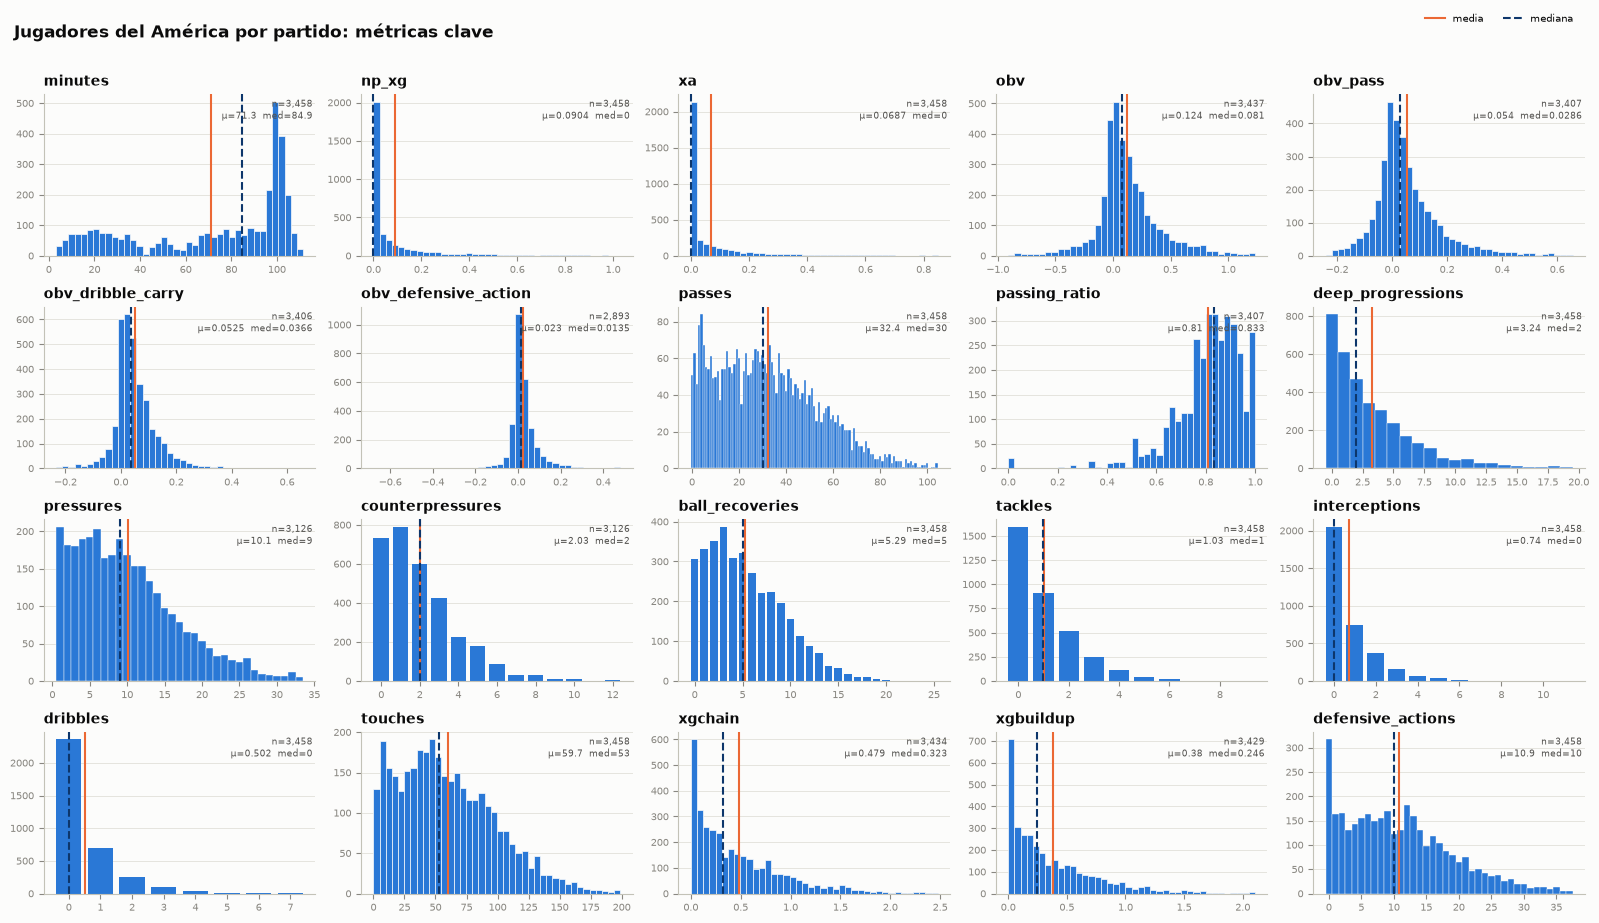

In [35]:
PKEY = ["minutes", "np_xg", "xa", "obv", "obv_pass", "obv_dribble_carry", "obv_defensive_action",
        "passes", "passing_ratio", "deep_progressions", "pressures", "counterpressures", "ball_recoveries",
        "tackles", "interceptions", "dribbles", "touches", "xgchain", "xgbuildup", "defensive_actions"]
PKEY = [c for c in PKEY if c in ps]
fig = eda.plot_numeric_grid(ps, PKEY, ncols=5, title="Jugadores del América por partido: métricas clave")
save(fig, "player_numericas_clave")

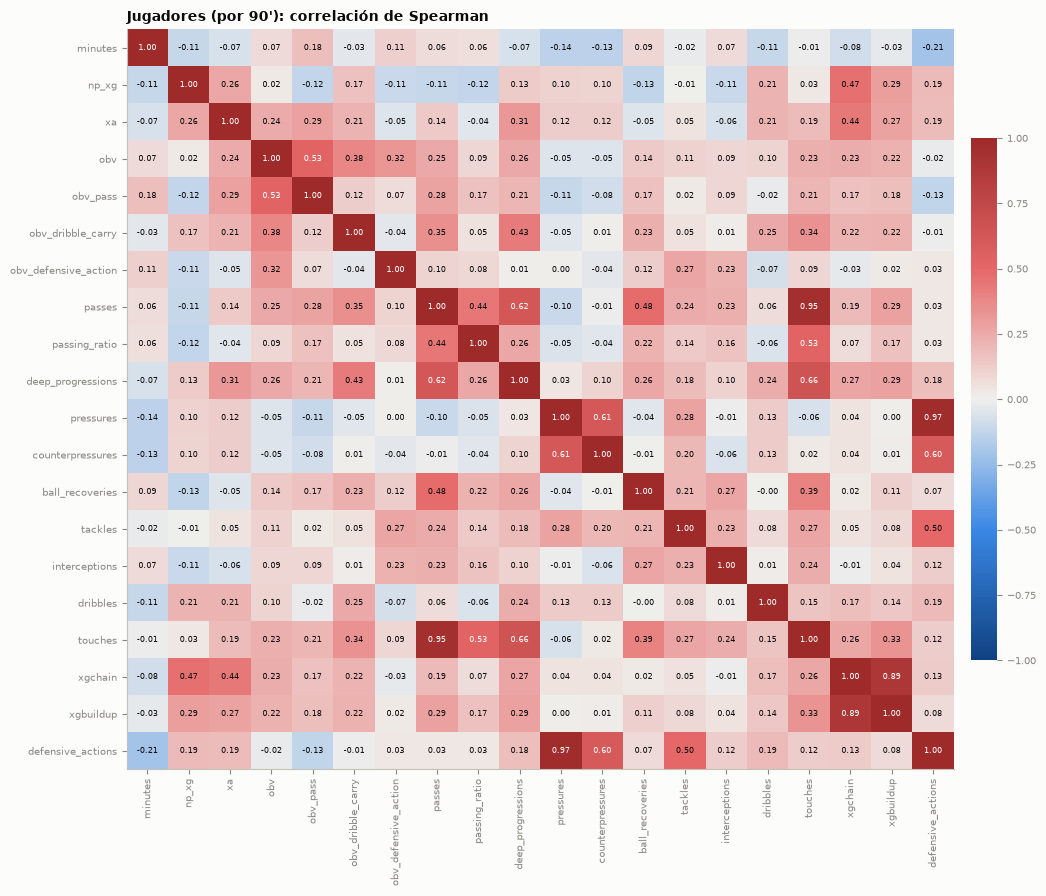

In [36]:
# Normalizando por 90 minutos (jugadores con >= 30')
p90 = ps[ps.minutes >= 30].copy()
for c in [c for c in PKEY if c not in ("minutes", "passing_ratio")]:
    p90[c] = p90[c] / p90.minutes * 90
pc90 = eda.correlation(p90, PKEY)
fig = eda.plot_heatmap(pc90, "Jugadores (por 90'): correlación de Spearman", size=9)
save(fig, "player_correlacion_p90")

In [37]:
mins = ps.groupby("player_name").agg(partidos=("match_id", "nunique"), minutos=("minutes", "sum"),
                                     obv_p90=("obv", "sum")).sort_values("minutos", ascending=False)
mins["obv_p90"] = (mins.obv_p90 / mins.minutos * 90).round(3)
show(mins, "player_minutos_totales", n=30)

,partidos,minutos,obv_p90
player_name,,,
Álvaro Fidalgo Fernández,184,"15,976.885",0.290
Alejandro Zendejas Saavedra,165,"12,628.729",0.237
Sebastián Enzo Cáceres Ramos,139,"12,513.443",0.097
Henry Josué Martín Mex,167,"12,149.033",0.037
Luis Ángel Malagón Velázquez,120,"12,102.402",0.061
Israel Reyes Romero,125,"11,330.671",0.186
Diego Alfonso Valdés Contreras,124,"9,190.080",0.180
Richard Rafael Sánchez Guerrero,128,"8,457.894",0.240
Kevin Nahin Álvarez Campos,103,"8,182.131",0.200


---
## 5. Alineaciones (`lineups`)
Columnas anidadas (`positions`, `formations`, `stats`, `events`) → se expanden para ver posiciones jugadas, formaciones y tarjetas.

In [38]:
lu = lineups[lineups.team == TEAM].copy()
lk = eda.classify_columns(lu)
show(lk.set_index("column"), "lineups_columnas")
show(eda.profile_numeric(lu, ["player_height", "player_weight", "jersey_number"]), "lineups_numericas")
lu["country_name"] = eda.parse_json_col(lu.country).map(lambda d: d.get("name") if isinstance(d, dict) else d)
show(eda.profile_categorical(lu, ["player_name", "country_name"]), "lineups_categoricas")

,kind,dtype,n_unique,pct_null,example
column,,,,,
player_id,id,int64,116,0.000,5526
player_name,categorical_high,str,116,0.000,Pedro Jesús Aquino Sánchez
player_nickname,categorical_high,str,99,3.580,Pedro Aquino
birth_date,datetime,str,116,0.000,1995-04-13
player_gender,categorical,str,1,0.000,male
player_height,numeric,float64,24,0.060,175.0
player_weight,numeric,float64,29,1.930,74.0
jersey_number,numeric,int64,78,0.000,5
positions,json,str,2480,0.000,"[{""position_id"": 9, ""position"": ""Right Defensi..."


,count,pct_null,n_unique,min,p5,p25,median,mean,p75,p95,max,std,mode,mode_pct,pct_zero,skew
column,,,,,,,,,,,,,,,,
player_height,4659,0.060,24,165.000,167.000,174.000,179.000,178.003,182.000,187.000,190.000,5.423,180.000,15.650,0.000,-0.301
player_weight,4572,1.930,29,52.000,64.000,68.000,73.000,73.320,77.000,85.000,87.000,6.285,66.000,10.080,0.000,0.135
jersey_number,4662,0.000,78,1.000,2.000,8.000,18.000,29.107,27.000,188.950,303.000,47.156,26.000,4.380,0.000,3.230


,count,pct_null,n_categories,mode,mode_pct,top_pct_cumulative,top_5
column,,,,,,,
player_name,4662,0.000,116,Álvaro Fidalgo Fernández,4.030,18.680,Álvaro Fidalgo Fernández (4.0%) | Henry Josué ...
country_name,4662,0.000,14,Mexico,64.860,89.660,Mexico (64.9%) | Uruguay (10.8%) | Chile (5.2%...


,count,pct_null,n_categories,mode,mode_pct,top_pct_cumulative,top_8
column,,,,,,,
position,4672,0.000,23,Right Defensive Midfield,8.010,57.040,Right Defensive Midfield (8.0%) | Left Defensi...
start_reason,4672,0.000,7,Starting XI,52.270,100.000,Starting XI (52.3%) | Tactical Shift (23.1%) |...
end_reason,4672,0.000,9,Final Whistle,51.820,99.910,Final Whistle (51.8%) | Tactical Shift (23.1%)...


Titulares con posición registrada: 2,442 (222 partidos)


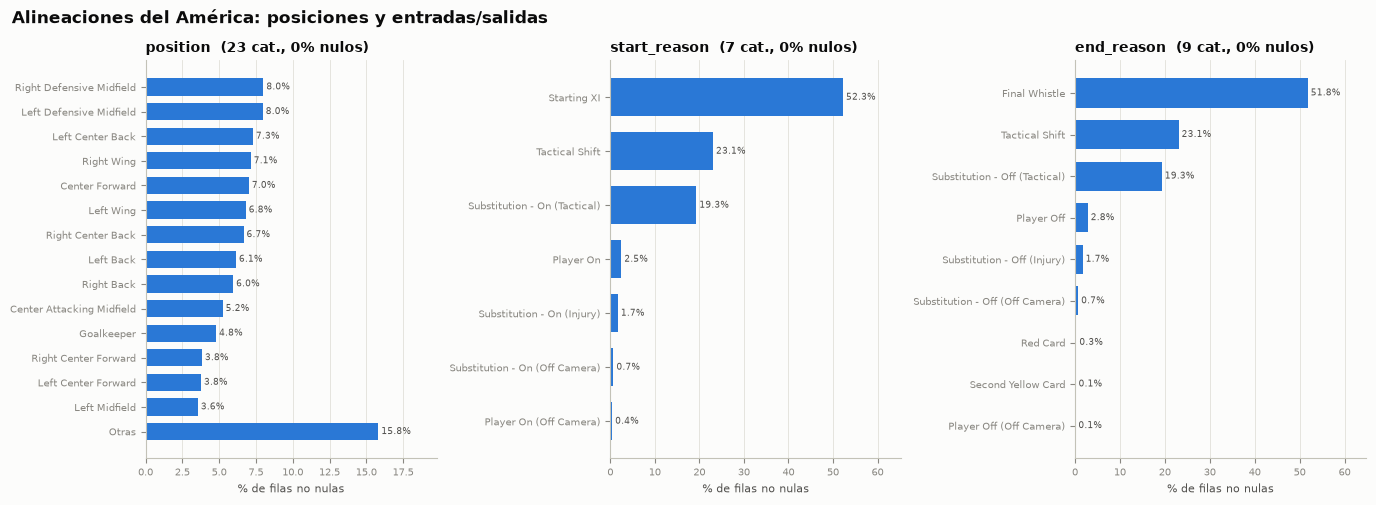

In [39]:
pos = lu[["match_id", "player_name", "positions"]].assign(positions=eda.parse_json_col(lu.positions)).explode("positions").dropna(subset=["positions"])
pos = pd.concat([pos.drop(columns="positions").reset_index(drop=True), pd.json_normalize(pos.positions.tolist())], axis=1)
show(eda.profile_categorical(pos, ["position", "start_reason", "end_reason"], top=8), "lineups_posiciones_categoricas")
starters = pos[pos.start_reason == "Starting XI"]
print(f"Titulares con posición registrada: {len(starters):,} ({starters.match_id.nunique()} partidos)")
fig = eda.plot_categorical_grid(pos, ["position", "start_reason", "end_reason"], ncols=3, top=14,
                                title="Alineaciones del América: posiciones y entradas/salidas")
save(fig, "lineups_posiciones")

In [40]:
# Formaciones del América (evento Starting XI, desde `tactics`)
xi = events[(events.type == "Starting XI") & (events.team == TEAM)].copy()
xi["formation"] = eda.parse_json_col(xi.tactics).map(lambda d: str(d.get("formation")) if isinstance(d, dict) else None)
xi = xi.merge(ctx[["match_id", "team_manager"]], on="match_id", suffixes=("", "_ctx"))
mcol = "team_manager_ctx" if "team_manager_ctx" in xi else "team_manager"
show(pd.crosstab(xi.formation, xi[mcol], margins=True), "formaciones_por_entrenador")

team_manager_ctx,André Soares Jardine,Diego Alberto Cervantes Chávez,Fernando Ortiz,Jorge Guillermo Almada Álves,Santiago Hernán Solari Poggio,All
formation,,,,,,
3412,0,0,1,0,0,1
3421,8,1,0,0,0,9
343,14,0,0,0,1,15
352,5,0,0,0,1,6
41212,1,0,1,0,1,3
4141,7,0,0,0,3,10
4231,57,1,33,8,12,111
433,9,0,2,0,2,13
4411,2,0,1,0,0,3


---
## 6. StatsBomb 360 (`frames360`)
Cada fila es un jugador visible en el cuadro de un evento. Se carga una **muestra** de partidos (la tabla completa es muy pesada).

In [41]:
sample_ids = played.match_id.sample(min(20, len(played)), random_state=1).tolist()
f360 = load_dataset("frames360", sample_ids)
f360 = eda.expand_xy(f360, cols=("location",))
fk = eda.classify_columns(f360)
show(fk.set_index("column"), "frames360_columnas")
per_frame = f360.groupby("id").agg(visibles=("teammate", "size"), companeros=("teammate", "sum"),
                                   con_portero=("keeper", "any"))
per_frame["rivales"] = per_frame.visibles - per_frame.companeros
show(eda.profile_numeric(per_frame, ["visibles", "companeros", "rivales"]), "frames360_por_evento")
show(eda.profile_boolean(f360, ["teammate", "actor", "keeper"]), "frames360_booleanas")
cov360 = events[events.match_id.isin(sample_ids)].id.isin(per_frame.index).mean()
print(f"% de eventos (muestra) con frame 360: {100 * cov360:.1f}%")

,kind,dtype,n_unique,pct_null,example
column,,,,,
id,id,str,"60,540.000",0.000,f6044f03-e450-5901-bbe5-bbe2e9dd8f8c
visible_area,coordinates,object,NaN,0.000,[87.01 0. 71.17 69.31 43.51 70.77 20. 0....
match_id,id,int64,20.000,0.000,3799416
teammate,boolean,object,2.000,0.090,True
actor,boolean,object,2.000,0.090,True
keeper,boolean,object,2.000,0.090,False
location,coordinates,object,NaN,0.090,[38. 45.7]
distance_from_edge_of_visible_area,numeric,float64,"3,646.000",0.090,2.67
location_x,numeric,float64,"1,306.000",0.090,38.0


,count,pct_null,n_unique,min,p5,p25,median,mean,p75,p95,max,std,mode,mode_pct,pct_zero,skew
column,,,,,,,,,,,,,,,,
visibles,60540,0.000,22,1,7.000,11.000,14.000,13.524,16.000,20.000,22,4.083,13,9.570,0.000,-0.322
companeros,60540,0.000,12,0,3.000,5.000,7.000,6.757,8.000,10.000,11,2.138,6,18.050,1.150,-0.248
rivales,60540,0.000,12,0,3.000,5.000,7.000,6.767,9.000,10.000,11,2.462,6,14.740,0.190,-0.263


,rows,n_true,n_false_explicit,n_null,pct_true
column,,,,,
teammate,818772,409099,408975,698,49.960
actor,818772,59842,758232,698,7.310
keeper,818772,20471,797603,698,2.500


% de eventos (muestra) con frame 360: 89.0%


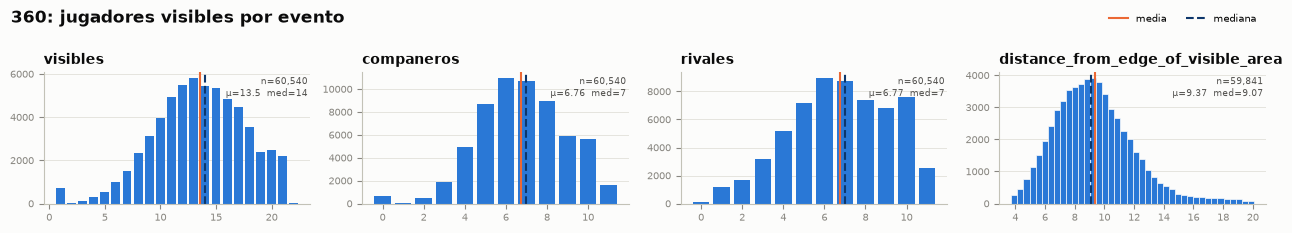

In [42]:
fig = eda.plot_numeric_grid(per_frame.join(f360.groupby("id").distance_from_edge_of_visible_area.mean()),
                            ["visibles", "companeros", "rivales", "distance_from_edge_of_visible_area"], ncols=4,
                            title="360: jugadores visibles por evento")
save(fig, "frames360_visibles")

---
## 7. Calidad de datos

In [43]:
checks = {
    "eventos duplicados (id)": int(events.id.duplicated().sum()),
    "eventos sin location": f"{100 * events.location_x.isna().mean():.1f}%",
    "location fuera de cancha": int(((events.location_x < 0) | (events.location_x > 120) | (events.location_y < 0) | (events.location_y > 80)).sum()),
    "partidos sin Starting XI del América": int(played.match_id.nunique() - xi.match_id.nunique()),
    "tiros sin xG": int(shots.shot_statsbomb_xg.isna().sum()),
    "filas team_stats del América": len(ts),
    "partidos jugados": len(played),
    "eventos por partido (media)": round(len(events) / events.match_id.nunique()),
    "team passing_ratio == opp_final_third_pass_ratio": f"{100 * np.isclose(ts.passing_ratio, ts.opp_final_third_pass_ratio).mean():.0f}% de partidos",
    "precisión de pase real (successful/passes), media": round(ts.pass_completion.mean(), 3),
}
pd.Series(checks).to_frame("valor")

,valor
eventos duplicados (id),0
eventos sin location,1.0%
location fuera de cancha,0
partidos sin Starting XI del América,0
tiros sin xG,0
filas team_stats del América,221
partidos jugados,222
eventos por partido (media),3319
team passing_ratio == opp_final_third_pass_ratio,100% de partidos
"precisión de pase real (successful/passes), media",0.829


In [44]:
# Tipos de evento sin location (esperado: Starting XI, Half Start/End, Substitution, Tactical Shift…)
events[events.location_x.isna()].type.value_counts().head(15).to_frame("sin_location")

,sin_location
type,
Substitution,1985
Injury Stoppage,1379
Half Start,894
Half End,894
Tactical Shift,729
Starting XI,444
Player Off,294
Player On,293
Bad Behaviour,253


---
## 8. Relación con el contexto (descriptivo)
El reto pide entender cómo cambian los patrones según **tiempo, marcador, localía y rival**. Aquí solo se describen esas relaciones (sin pruebas estadísticas ni conclusiones) para orientar hipótesis.

**Definiciones preliminares** (se formalizarán en el marco analítico):
- **Field tilt** = pases del América en el último tercio (`x ≥ 80`) / pases de ambos equipos en su último tercio.
- **Pase progresivo** = pase completo de juego abierto (`pass_type` nulo) que reduce ≥ 25% la distancia a la portería rival y termina en `x ≥ 48`.
- **Estado del marcador** = diferencia de goles del América *antes* de cada evento (goles de tiro + autogoles; se excluye la tanda de penales, `period = 5`).
- **Nivel del rival** = puntos por partido del rival en esa temporada StatsBomb (todos sus partidos de Liga MX), en tercios: Alto / Medio / Bajo.

In [45]:
COACH_ORDER = ["Santiago Hernán Solari Poggio", "Fernando Ortiz", "André Soares Jardine",
               "Diego Alberto Cervantes Chávez", "Jorge Guillermo Almada Álves"]
COACH_SHORT = {"Santiago Hernán Solari Poggio": "Solari", "Fernando Ortiz": "Ortiz", "André Soares Jardine": "Jardine",
               "Diego Alberto Cervantes Chávez": "Cervantes", "Jorge Guillermo Almada Álves": "Almada"}
COACH_COLOR = dict(zip(COACH_ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))  # color fijo por entrenador
MAIN = ["Solari", "Ortiz", "Jardine", "Almada"]  # Cervantes (2 partidos, interino) se omite en comparaciones

# --- métricas por partido construidas desde eventos
ev = events
is_pass = ev.type == "Pass"
f3 = is_pass & (ev.location_x >= 80)
completed = is_pass & ev.pass_outcome.isna()
d0 = np.hypot(120 - ev.location_x, 40 - ev.location_y)
d1 = np.hypot(120 - ev.pass_end_location_x, 40 - ev.pass_end_location_y)
progressive = completed & ev.pass_type.isna() & (d1 <= 0.75 * d0) & (ev.pass_end_location_x >= 48)
am_ev = ev.team == TEAM
g = pd.DataFrame({"match_id": ev.match_id, "am": am_ev, "f3": f3, "prog": progressive, "pass": is_pass})
pm = pd.DataFrame({
    "field_tilt": g[g.f3].groupby("match_id").am.mean(),
    "progressive_passes": g[g.prog & g.am].groupby("match_id").size(),
    "progressive_passes_rival": g[g.prog & ~g.am].groupby("match_id").size(),
    "pass_x_mean": ev[is_pass & am_ev].groupby("match_id").location_x.mean(),
    "pressure_x_mean": ev[(ev.type == "Pressure") & am_ev].groupby("match_id").location_x.mean(),
})
per_match = (played.set_index("match_id")[["match_date", "season", "team_manager", "opponent", "is_home", "result", "goals_for", "goals_against"]]
             .join(pm).join(ts.set_index("match_id")[["possession", "ppda", "np_xg", "np_xg_conceded", "obv", "obv_conceded",
                                                      "pass_completion", "gk_long_pass_ratio", "defensive_distance",
                                                      "deep_progressions", "counterpressures", "sp_xg", "sp_xg_conceded"]])
             .sort_values("match_date").reset_index())
per_match["coach"] = per_match.team_manager.map(COACH_SHORT)
# torneo (Apertura = jul–dic, Clausura = ene–jun) y fase (regular vs liguilla)
stage = matches.set_index("match_id").competition_stage
per_match["competition_stage"] = per_match.match_id.map(stage)
per_match["torneo"] = np.where(per_match.match_date.str[5:7].astype(int) >= 7, "Apertura ", "Clausura ") + per_match.match_date.str[:4]
per_match["fase"] = np.where(per_match.competition_stage.isin(["Apertura", "Clausura", "Regular Season"]), "Fase regular", "Liguilla")
CTX_METRICS = ["possession", "field_tilt", "ppda", "defensive_distance", "pressure_x_mean", "pass_x_mean",
               "progressive_passes", "pass_completion", "gk_long_pass_ratio", "np_xg", "np_xg_conceded", "obv"]
show(eda.profile_numeric(per_match, ["field_tilt", "progressive_passes", "progressive_passes_rival", "pass_x_mean", "pressure_x_mean"]),
     "contexto_metricas_nuevas")

,count,pct_null,n_unique,min,p5,p25,median,mean,p75,p95,max,std,mode,mode_pct,pct_zero,skew
column,,,,,,,,,,,,,,,,
field_tilt,222,0.000,219,0.139,0.316,0.504,0.606,0.598,0.719,0.816,0.912,0.153,0.591,0.900,0.000,-0.512
progressive_passes,222,0.000,47,13.000,20.050,27.250,35.000,35.041,41.000,52.000,62.000,9.973,31.000,4.950,0.000,0.329
progressive_passes_rival,222,0.000,41,10.000,14.000,22.000,27.000,27.887,33.000,42.000,54.000,8.576,30.000,7.210,0.000,0.452
pass_x_mean,222,0.000,222,42.001,50.679,55.658,58.595,58.605,62.062,66.606,72.954,4.881,61.093,0.450,0.000,-0.103
pressure_x_mean,222,0.000,222,44.016,49.135,53.497,57.926,57.740,61.495,66.645,72.052,5.521,64.606,0.450,0.000,0.030


### 8.1 Evolución en el tiempo (partido a partido, media móvil de 8 partidos)

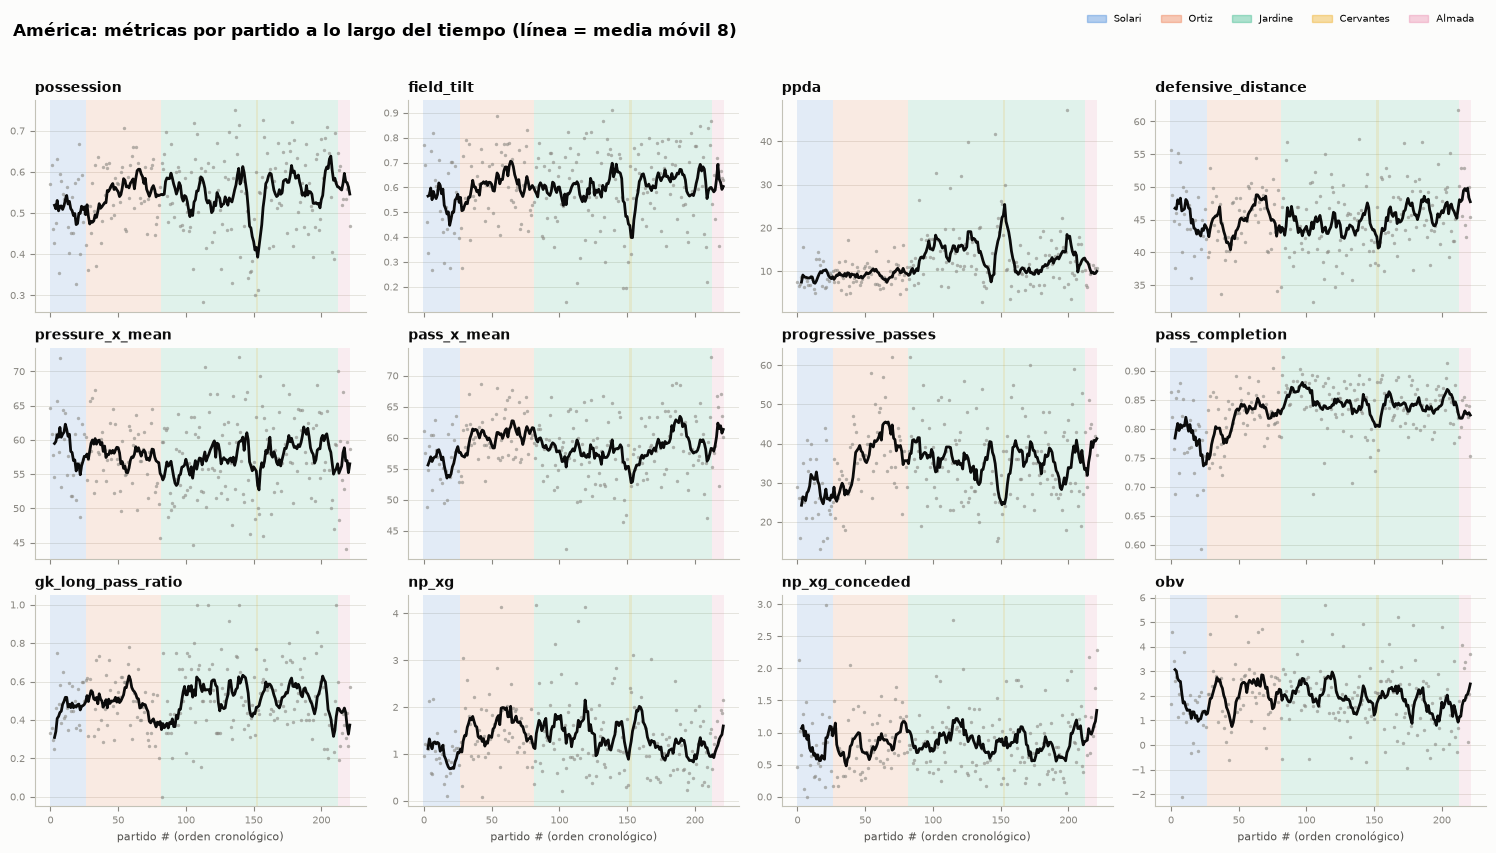

In [46]:
fig, axes = plt.subplots(3, 4, figsize=(15, 8.5), sharex=True)
x = np.arange(len(per_match))
for ax, m in zip(axes.flat, CTX_METRICS):
    for coach in COACH_ORDER:
        idx = np.where(per_match.team_manager == coach)[0]
        if len(idx):
            ax.axvspan(idx.min() - .5, idx.max() + .5, color=COACH_COLOR[coach], alpha=.12, lw=0)
    ax.scatter(x, per_match[m], s=6, color=eda.MUTED, alpha=.6, lw=0)
    ax.plot(x, per_match[m].rolling(8, min_periods=4).mean(), color=eda.INK, lw=2)
    ax.set_title(m, loc="left"); ax.grid(axis="x", visible=False)
for ax in axes[-1]:
    ax.set_xlabel("partido # (orden cronológico)")
handles = [plt.Rectangle((0, 0), 1, 1, color=COACH_COLOR[c], alpha=.35) for c in COACH_ORDER]
fig.legend(handles, [COACH_SHORT[c] for c in COACH_ORDER], loc="upper right", ncol=5, bbox_to_anchor=(.99, 1.0))
fig.suptitle("América: métricas por partido a lo largo del tiempo (línea = media móvil 8)", x=.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, .96))
save(fig, "contexto_series_tiempo")

In [47]:
# Medianas por torneo (Apertura / Clausura)
TORNEO_METRICS = ["possession", "field_tilt", "ppda", "pressure_x_mean", "progressive_passes", "pass_completion",
                  "gk_long_pass_ratio", "np_xg", "np_xg_conceded", "obv"]
tor = per_match.groupby(["torneo", "coach"], sort=False)[TORNEO_METRICS].median().round(2)
tor["partidos"] = per_match.groupby(["torneo", "coach"], sort=False).size()
tor["% victorias"] = per_match.groupby(["torneo", "coach"], sort=False).result.apply(lambda r: round(100 * (r == "W").mean()))
show(tor, "contexto_por_torneo")

possession  field_tilt   ppda  pressure_x_mean  progressive_passes  pass_completion  gk_long_pass_ratio  np_xg  np_xg_conceded   obv  partidos  % victorias
torneo        coach                                                                                                                                                                 
Apertura 2021 Solari          0.540       0.580  7.690           60.140              26.000            0.810               0.450  0.950           0.640 1.660        19           53
Clausura 2022 Solari          0.490       0.570  8.670           58.810              23.500            0.770               0.530  1.100           0.840 1.390         8           12
              Ortiz           0.510       0.560  8.390           58.290              31.000            0.770               0.470  1.450           0.690 2.390        13           54
Apertura 2022 Ortiz           0.570       0.620  9.380           57.080              40.000            0.830               0.560  1.520           0.790 1.930        21           67
Clausura 2023 Ortiz           0.550       0.590  8.730           57.700              38.000            0.820               0.420  1.430           0.880 2.100        21           52
Apertura 2023 Jardine         0.530       0.610 13.120           56.610              38.000            0.870               0.450  1.340           0.760 2.260        23           65
Clausura 2024 Jardine         0.550       0.580 14.120           55.810              35.000            0.840               0.500  1.030           1.030 2.060        23           52
Apertura 2024 Jardine         0.530       0.590 12.510           56.670              30.500            0.850               0.500  1.140           0.750 1.550        24           50
Clausura 2025 Cervantes       0.460       0.510 24.070           56.700              31.000            0.820               0.610  2.360           0.610 2.120         2           50
              Jardine         0.580       0.630 10.330           58.450              36.000            0.840               0.540  1.260           0.650 2.500        21           52
Apertura 2025 Jardine         0.550       0.640 11.860           59.770              32.000            0.840               0.500  1.020           0.730 1.710        19           58
Clausura 2026 Jardine         0.610       0.680 12.400           59.350              30.000            0.850               0.500  1.040           0.850 1.020        19           37
Apertura 2026 Almada          0.560       0.640  9.760           55.900              41.000            0.830               0.330  1.360           1.100 2.090         9           67

### 8.2 Distribución por entrenador (mediana y rango intercuartílico)

In [48]:
def med_iqr(s):
    return f"{s.median():.2f} [{s.quantile(.25):.2f}–{s.quantile(.75):.2f}]"
by_coach = per_match[per_match.coach.isin(MAIN)].groupby("coach")[CTX_METRICS].agg(med_iqr).T[MAIN]
by_coach.loc["partidos"] = per_match.coach.value_counts()[MAIN].astype(str)
show(by_coach, "contexto_por_entrenador")

coach,Solari,Ortiz,Jardine,Almada
possession,0.53 [0.45–0.58],0.55 [0.51–0.61],0.56 [0.47–0.63],0.56 [0.53–0.58]
field_tilt,0.58 [0.43–0.69],0.60 [0.52–0.72],0.61 [0.52–0.73],0.64 [0.53–0.67]
ppda,8.18 [6.72–9.87],8.73 [7.50–10.97],12.15 [9.57–16.40],9.76 [9.42–10.77]
defensive_distance,44.72 [42.74–47.81],45.42 [41.77–48.20],44.94 [41.51–48.54],48.66 [45.38–50.11]
pressure_x_mean,60.14 [54.88–61.59],57.26 [54.04–60.54],58.02 [52.72–61.76],55.90 [52.81–59.70]
pass_x_mean,56.90 [53.46–59.96],59.68 [57.81–62.78],58.39 [54.91–62.02],60.16 [57.48–64.93]
progressive_passes,26.00 [22.00–34.00],36.00 [31.00–42.50],34.00 [28.00–42.00],41.00 [37.00–44.00]
pass_completion,0.79 [0.76–0.82],0.83 [0.80–0.85],0.85 [0.83–0.87],0.83 [0.80–0.84]
gk_long_pass_ratio,0.46 [0.37–0.58],0.50 [0.38–0.60],0.50 [0.40–0.67],0.33 [0.27–0.43]
np_xg,1.00 [0.79–1.18],1.46 [1.18–1.94],1.19 [0.76–1.70],1.36 [1.26–1.87]


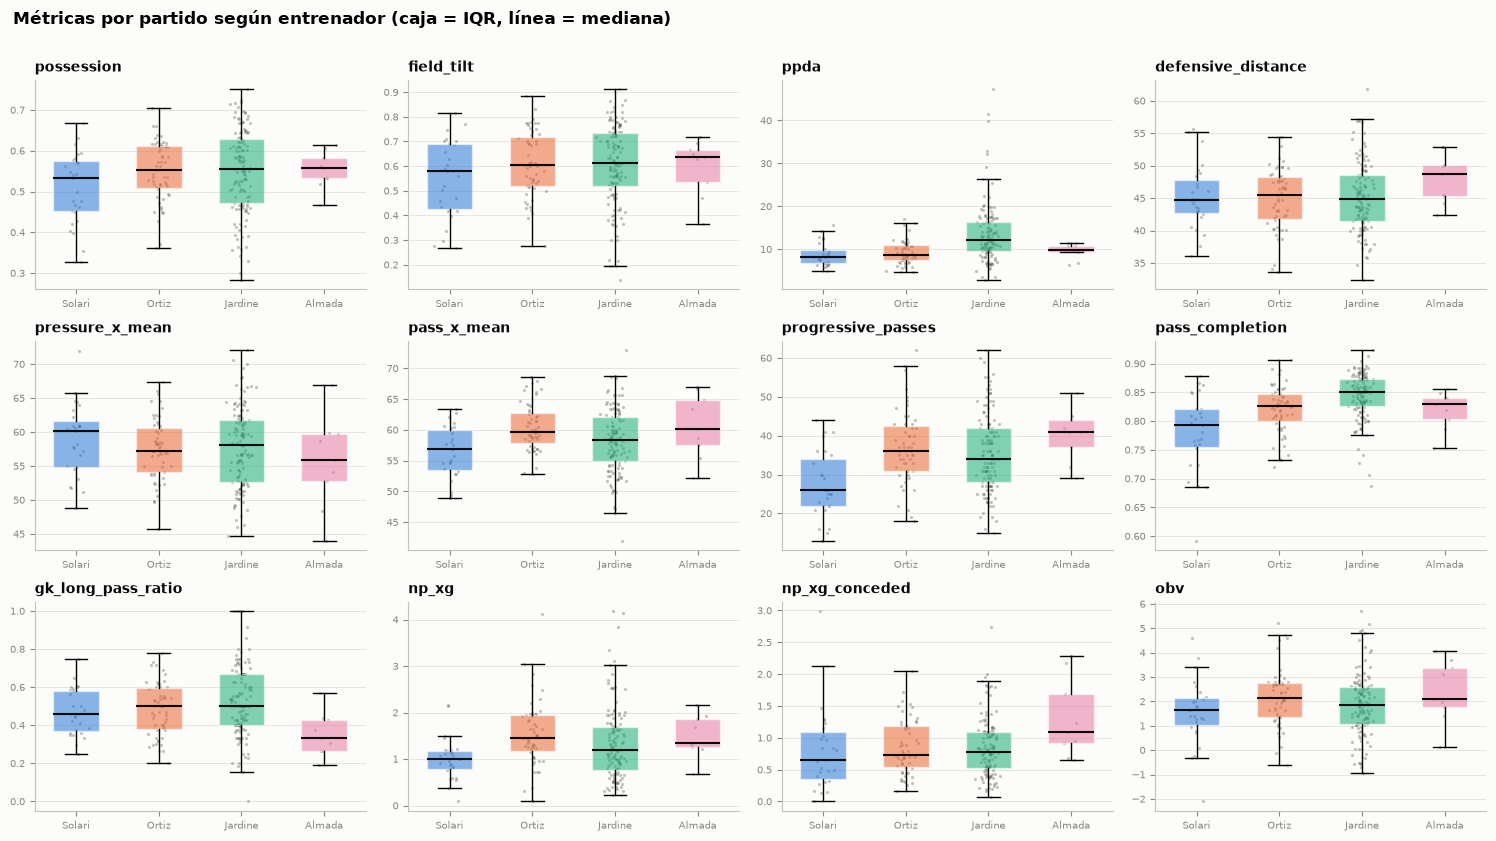

In [49]:
fig, axes = plt.subplots(3, 4, figsize=(15, 8.5))
sub = per_match[per_match.coach.isin(MAIN)]
FULL = {v: k for k, v in COACH_SHORT.items()}
rng = np.random.default_rng(0)
for ax, m in zip(axes.flat, CTX_METRICS):
    data = [sub.loc[sub.coach == c, m].dropna() for c in MAIN]
    bp = ax.boxplot(data, widths=.55, patch_artist=True, showfliers=False, medianprops=dict(color=eda.INK, lw=1.5))
    for patch, c in zip(bp["boxes"], MAIN):
        patch.set_facecolor(COACH_COLOR[FULL[c]]); patch.set_alpha(.55); patch.set_edgecolor(eda.SURFACE)
    for i, d in enumerate(data, 1):
        ax.scatter(rng.normal(i, .06, len(d)), d, s=5, color=eda.INK_2, alpha=.35, lw=0)
    ax.set_xticks(range(1, len(MAIN) + 1), MAIN); ax.set_title(m, loc="left"); ax.grid(axis="x", visible=False)
fig.suptitle("Métricas por partido según entrenador (caja = IQR, línea = mediana)", x=.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, .97))
save(fig, "contexto_boxplots_entrenador")

### 8.3 Localía

In [50]:
pm_main = per_match[per_match.coach.isin(MAIN)].assign(localia=lambda d: np.where(d.is_home, "Local", "Visita"))
loc = pm_main.groupby(["coach", "localia"])[CTX_METRICS + ["goals_for", "goals_against"]].median().round(2)
loc["partidos"] = pm_main.groupby(["coach", "localia"]).size()
show(loc.T[MAIN], "contexto_localia")

coach              Solari         Ortiz        Jardine        Almada       
localia             Local Visita  Local Visita   Local Visita  Local Visita
possession          0.540  0.480  0.580  0.520   0.560  0.560  0.530  0.580
field_tilt          0.630  0.500  0.690  0.580   0.660  0.600  0.560  0.650
ppda                6.900  8.740  9.380  7.870  12.440 11.530 11.140  9.550
defensive_distance 46.060 43.600 46.620 43.900  45.460 43.270 47.710 48.660
pressure_x_mean    60.740 54.930 58.250 56.790  59.510 55.760 54.990 58.720
pass_x_mean        57.230 54.850 59.670 59.740  58.790 57.780 61.090 60.160
progressive_passes 26.000 24.000 37.000 35.500  36.000 33.000 43.000 37.000
pass_completion     0.810  0.760  0.840  0.810   0.860  0.840  0.840  0.800
gk_long_pass_ratio  0.570  0.440  0.500  0.490   0.500  0.500  0.320  0.380
np_xg               0.960  1.070  1.520  1.410   1.260  1.060  1.530  1.260
np_xg_conceded      0.650  0.650  0.690  0.880   0.660  0.900  1.320  1.100
obv                 1.310  1.660  2.480  2.090   1.990  1.590  2.620  1.780
goals_for           1.500  1.000  2.000  2.000   2.000  1.000  2.500  2.000
goals_against       0.500  1.000  1.000  1.000   0.500  1.000  0.000  1.000
partidos           14.000 13.000 27.000 28.000  64.000 65.000  4.000  5.000

### 8.4 Nivel del rival
Se descargan los resultados de *toda* la liga (solo la lista de partidos) para calcular puntos por partido de cada rival.

In [51]:
from src.sb_client import get_creds, LIGA_MX, SEASONS_LIGA_MX
from statsbombpy import sb
league_path = RAW / "matches_liga_mx_all.parquet"
if league_path.exists():
    league = pd.read_parquet(league_path)
else:
    creds = get_creds()
    league = pd.concat([sb.matches(competition_id=LIGA_MX, season_id=s, creds=creds) for s in SEASONS_LIGA_MX], ignore_index=True)
    league = league[["match_id", "season", "match_date", "home_team", "away_team", "home_score", "away_score", "match_status"]]
    league.to_parquet(league_path)
lg = league[league.match_status == "available"]
long = pd.concat([
    pd.DataFrame({"season": lg.season, "team": lg.home_team, "pts": np.select([lg.home_score > lg.away_score, lg.home_score == lg.away_score], [3, 1], 0)}),
    pd.DataFrame({"season": lg.season, "team": lg.away_team, "pts": np.select([lg.away_score > lg.home_score, lg.home_score == lg.away_score], [3, 1], 0)})])
ppg = long.groupby(["season", "team"]).pts.mean().rename("rival_ppg").reset_index()
ppg["rival_tier"] = ppg.groupby("season").rival_ppg.transform(lambda s: pd.qcut(s.rank(method="first"), 3, labels=["Bajo", "Medio", "Alto"]).astype(str))
per_match = per_match.merge(ppg.rename(columns={"team": "opponent"}), on=["season", "opponent"], how="left")
per_match.to_parquet(PROCESSED / "per_match_america.parquet")
pm_main = per_match[per_match.coach.isin(MAIN)]
tier = pm_main.groupby(["coach", "rival_tier"])[CTX_METRICS + ["goals_for", "goals_against"]].median().round(2)
tier["partidos"] = pm_main.groupby(["coach", "rival_tier"]).size()
show(tier.T[MAIN], "contexto_nivel_rival")

coach              Solari                Ortiz               Jardine               Almada              
rival_tier           Alto   Bajo  Medio   Alto   Bajo  Medio    Alto   Bajo  Medio   Alto   Bajo  Medio
possession          0.480  0.580  0.470  0.540  0.570  0.540   0.510  0.600  0.570  0.580  0.530  0.550
field_tilt          0.520  0.680  0.470  0.550  0.610  0.600   0.560  0.680  0.640  0.590  0.650  0.520
ppda                8.920  7.520  8.180  8.430  8.670  9.380  15.210 10.960 11.360  8.800  9.550 10.650
defensive_distance 44.290 44.910 44.920 42.260 46.620 46.780  43.480 46.090 45.420 50.010 45.500 45.530
pressure_x_mean    58.190 60.880 57.780 54.830 58.250 58.290  55.850 59.610 59.690 52.130 58.720 51.860
pass_x_mean        55.130 60.350 54.650 60.460 61.200 59.130  56.540 58.750 58.780 59.400 60.160 59.620
progressive_passes 26.000 30.000 22.000 36.000 37.000 35.000  32.500 38.000 35.000 37.000 44.000 41.000
pass_completion     0.760  0.820  0.770  0.830  0.830  0.820   0.840  0.870  0.850  0.810  0.830  0.830
gk_long_pass_ratio  0.560  0.460  0.420  0.380  0.500  0.530   0.470  0.500  0.520  0.230  0.380  0.370
np_xg               1.110  1.070  0.920  1.320  1.830  1.460   0.930  1.710  1.170  1.280  1.360  1.620
np_xg_conceded      0.650  0.470  0.840  0.940  0.720  0.720   0.830  0.800  0.740  1.300  1.240  1.020
obv                 2.020  1.660  1.380  1.950  2.480  2.340   1.490  2.480  1.850  1.940  3.360  1.040
goals_for           1.000  1.000  1.000  2.000  2.000  2.000   1.000  2.000  1.000  1.500  3.000  2.500
goals_against       1.000  1.000  1.000  1.000  1.000  1.000   1.000  1.000  1.000  1.000  1.000  2.000
partidos            7.000  9.000 11.000 19.000 15.000 21.000  46.000 35.000 48.000  2.000  5.000  2.000

In [52]:
# Resultado según nivel del rival
res_tier = pd.crosstab([pm_main.coach, pm_main.rival_tier], pm_main.result, normalize="index").mul(100).round(1)[["W", "D", "L"]]
res_tier["partidos"] = pm_main.groupby(["coach", "rival_tier"]).size()
show(res_tier.loc[MAIN], "contexto_resultado_nivel_rival")

result                  W      D      L  partidos
coach   rival_tier                               
Solari  Alto       28.600 42.900 28.600         7
        Bajo       44.400 22.200 33.300         9
        Medio      45.500 36.400 18.200        11
Ortiz   Alto       52.600 15.800 31.600        19
        Bajo       80.000 13.300  6.700        15
        Medio      47.600 42.900  9.500        21
Jardine Alto       39.100 34.800 26.100        46
        Bajo       74.300 17.100  8.600        35
        Medio      50.000 29.200 20.800        48
Almada  Alto       50.000 50.000  0.000         2
        Bajo       80.000 20.000  0.000         5
        Medio      50.000  0.000 50.000         2

### 8.5 Fase del torneo: regular vs. liguilla

In [53]:
fase = pm_main.groupby(["coach", "fase"])[CTX_METRICS + ["goals_for", "goals_against"]].median().round(2)
fase["partidos"] = pm_main.groupby(["coach", "fase"]).size()
show(fase.T[MAIN], "contexto_fase_torneo")

coach                    Solari                 Ortiz               Jardine                Almada
fase               Fase regular Liguilla Fase regular Liguilla Fase regular Liguilla Fase regular
possession                0.530    0.510        0.560    0.530        0.580    0.520        0.560
field_tilt                0.580    0.550        0.610    0.560        0.630    0.560        0.640
ppda                      8.180    8.970        8.780    6.940       11.560   14.140        9.760
defensive_distance       44.720   42.150       45.420   45.580       44.980   43.480       48.660
pressure_x_mean          60.140   57.890       57.700   56.150       58.590   56.590       55.900
pass_x_mean              56.900   55.260       59.130   60.040       58.320   58.450       60.160
progressive_passes       26.000   21.500       37.000   35.000       36.000   29.000       41.000
pass_completion           0.790    0.760        0.830    0.800        0.860    0.830        0.830
gk_long_pass_ratio        0.460    0.470        0.500    0.390        0.500    0.480        0.330
np_xg                     1.070    0.480        1.520    1.300        1.190    1.060        1.360
np_xg_conceded            0.650    0.880        0.720    1.020        0.800    0.780        1.100
obv                       1.660    1.540        2.100    2.360        1.930    1.490        2.090
goals_for                 1.000    0.500        2.000    1.000        2.000    1.000        2.000
goals_against             1.000    1.500        1.000    1.000        1.000    1.000        1.000
partidos                 25.000    2.000       43.000   12.000      100.000   29.000        9.000

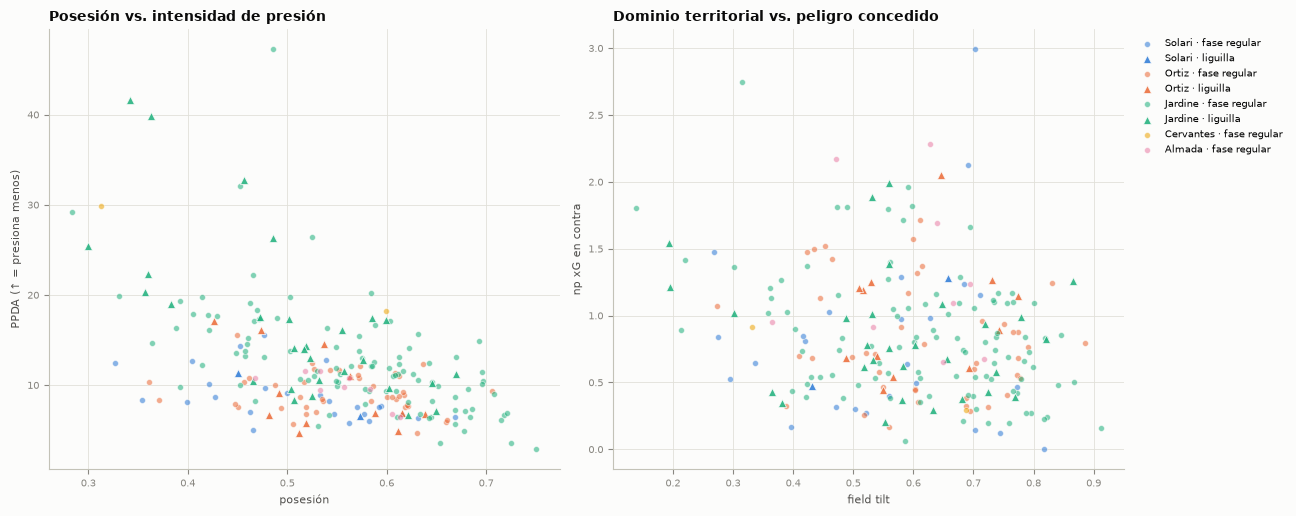

In [54]:
# Plano de estilo: posesión vs. PPDA por partido (color = entrenador, triángulo = liguilla)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, (xm, ym, xl, yl) in zip(axes, [("possession", "ppda", "posesión", "PPDA (↑ = presiona menos)"),
                                       ("field_tilt", "np_xg_conceded", "field tilt", "np xG en contra")]):
    for coach in COACH_ORDER:
        d = per_match[per_match.team_manager == coach]
        for fz, mk in [("Fase regular", "o"), ("Liguilla", "^")]:
            dd = d[d.fase == fz]
            ax.scatter(dd[xm], dd[ym], s=34 if mk == "^" else 18, marker=mk, color=COACH_COLOR[coach],
                       alpha=.85 if mk == "^" else .55, edgecolor=eda.SURFACE, lw=.6,
                       label=f"{COACH_SHORT[coach]} · {fz.lower()}" if len(dd) else None)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
axes[0].set_title("Posesión vs. intensidad de presión", loc="left")
axes[1].set_title("Dominio territorial vs. peligro concedido", loc="left")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7)
fig.tight_layout()
save(fig, "contexto_plano_estilo")

### 8.6 Estado del marcador

In [55]:
ev = events[events.period < 5].sort_values(["match_id", "index"])
is_goal = ((ev.type == "Shot") & (ev.shot_outcome == "Goal")) | (ev.type == "Own Goal For")
goal_am = is_goal & (ev.team == TEAM)
goal_op = is_goal & (ev.team != TEAM)
gf = goal_am.groupby(ev.match_id).cumsum() - goal_am   # goles ANTES del evento
ga = goal_op.groupby(ev.match_id).cumsum() - goal_op
ev = ev.assign(score_diff=(gf - ga).astype(int))
ev["estado"] = np.select([ev.score_diff > 0, ev.score_diff < 0], ["Ganando", "Perdiendo"], "Empatando")
ev["coach"] = ev.team_manager.map(COACH_SHORT)

# validación: goles reconstruidos vs. marcador oficial (sin tanda de penales)
chk = pd.DataFrame({"gf": goal_am.groupby(ev.match_id).sum(), "ga": goal_op.groupby(ev.match_id).sum()}).join(
    played.set_index("match_id")[["goals_for", "goals_against"]])
print(f"Partidos con marcador reconstruido == oficial: {((chk.gf == chk.goals_for) & (chk.ga == chk.goals_against)).mean():.1%}")

am = ev.team == TEAM
pas = ev[ev.type == "Pass"]
prs = ev[am & (ev.type == "Pressure")]
keys = ["coach", "estado"]
state = pd.DataFrame({
    "% eventos del partido": ev.groupby(keys).size() / ev.groupby("coach").size() * 100,
    "% pases del América (≈posesión)": pas.assign(a=pas.team == TEAM).groupby(keys).a.mean() * 100,
    "x media pases América": pas[pas.team == TEAM].groupby(keys).location_x.mean(),
    "x media presiones América": prs.groupby(keys).location_x.mean(),
    "% presiones en campo rival": prs.assign(h=prs.location_x >= 60).groupby(keys).h.mean() * 100,
    "xG América por 100 pases": ev[am].groupby(keys).shot_statsbomb_xg.sum() / pas[pas.team == TEAM].groupby(keys).size() * 100,
    "xG rival por 100 pases rival": ev[~am].groupby(keys).shot_statsbomb_xg.sum() / pas[pas.team != TEAM].groupby(keys).size() * 100,
}).round(2)
state = state.loc[[c for c in MAIN if c in state.index.get_level_values(0)]]
show(state, "contexto_estado_marcador")

Partidos con marcador reconstruido == oficial: 100.0%


% eventos del partido  % pases del América (≈posesión)  x media pases América  x media presiones América  % presiones en campo rival  xG América por 100 pases  xG rival por 100 pases rival
coach   estado                                                                                                                                                                                                 
Solari  Empatando                 63.710                           51.400                 55.640                     60.240                      49.490                     0.240                         0.160
        Ganando                   21.300                           42.660                 56.700                     55.780                      43.320                     0.400                         0.270
        Perdiendo                 14.990                           60.810                 61.120                     58.200                      48.010                     0.280                         0.460
Ortiz   Empatando                 43.380                           56.390                 60.930                     59.440                      49.720                     0.290                         0.240
        Ganando                   37.930                           50.400                 58.330                     54.730                      41.240                     0.430                         0.240
        Perdiendo                 18.690                           61.920                 64.550                     57.410                      46.310                     0.330                         0.230
Jardine Empatando                 53.990                           55.170                 58.540                     58.720                      48.180                     0.260                         0.190
        Ganando                   31.020                           50.430                 56.210                     53.890                      39.950                     0.350                         0.220
        Perdiendo                 14.990                           63.290                 63.450                     61.960                      53.270                     0.320                         0.260
Almada  Empatando                 41.240                           57.870                 60.210                     58.510                      48.210                     0.300                         0.400
        Ganando                   44.250                           50.520                 57.770                     54.110                      41.500                     0.310                         0.290
        Perdiendo                 14.510                           60.100                 68.700                     55.630                      44.640                     0.750                         0.510

### 8.7 Balón parado

In [56]:
shots_ctx = events[(events.type == "Shot") & (events.period < 5)].assign(
    coach=lambda d: d.team_manager.map(COACH_SHORT), lado=lambda d: np.where(d.team == TEAM, "América", "Rival"))
shots_ctx = shots_ctx[shots_ctx.coach.isin(MAIN)]
sp = (shots_ctx.groupby(["lado", "coach", "play_pattern"]).shot_statsbomb_xg.sum()
      / shots_ctx.groupby(["lado", "coach"]).shot_statsbomb_xg.sum() * 100).round(1)
cols_pp = ["Regular Play", "From Counter", "From Corner", "From Free Kick", "From Throw In", "From Goal Kick", "From Keeper", "From Kick Off"]
sp = sp.unstack("play_pattern").fillna(0)
show(sp[[c for c in cols_pp if c in sp]], "contexto_balon_parado_xg_share")

play_pattern     Regular Play  From Counter  From Corner  From Free Kick  From Throw In  From Goal Kick  From Keeper  From Kick Off
lado    coach                                                                                                                      
América Almada         49.100         7.700       20.200           9.200          8.600           1.600        2.600          0.900
        Jardine        52.300         2.400       12.700          15.700         10.900           3.300        1.900          0.700
        Ortiz          50.400         3.000       11.800          14.400         12.500           4.700        2.100          1.100
        Solari         53.100         0.100       15.500          16.800          9.800           2.400        1.000          1.400
Rival   Almada         47.500         0.200       14.600           4.200         21.400           5.600        6.400          0.200
        Jardine        43.900         2.800       18.400          12.300         14.600           5.400        1.600          1.100
        Ortiz          50.800         2.300       14.900          14.400          9.900           5.400        1.400          0.900
        Solari         55.800         0.900       12.000          19.800          8.100           3.100        0.100          0.100

### 8.8 Sustituciones y cambios de sistema

In [57]:
n_matches = per_match.coach.value_counts()
subs = ev[(ev.type == "Substitution") & (ev.team == TEAM) & ev.coach.isin(MAIN)]
subs_tbl = subs.groupby("coach").agg(cambios=("id", "size"), minuto_mediano=("minute", "median"),
                                     pct_al_medio_tiempo=("minute", lambda m: 100 * ((m >= 45) & (m <= 46)).mean()))
subs_tbl["cambios_por_partido"] = subs_tbl.cambios / n_matches
first = subs.groupby("match_id").agg(primer_cambio=("minute", "min"), coach=("coach", "first"))
subs_tbl["minuto_primer_cambio_mediano"] = first.groupby("coach").primer_cambio.median()
subs_state = subs.groupby(["coach", "estado"]).size().unstack(fill_value=0)
subs_tbl = subs_tbl.join(subs_state.div(subs_state.sum(1), axis=0).mul(100).round(1).add_prefix("% cambios "))
show(subs_tbl.loc[MAIN].round(2), "contexto_sustituciones")

shifts = ev[(ev.type == "Tactical Shift") & (ev.team == TEAM) & ev.coach.isin(MAIN)]
shift_tbl = (shifts.groupby("coach").size() / n_matches).loc[MAIN].round(2).to_frame("cambios_tacticos_por_partido")
sh_state = shifts.groupby(["coach", "estado"]).size().unstack(fill_value=0)
shift_tbl = shift_tbl.join(sh_state.div(sh_state.sum(1), axis=0).mul(100).round(1).add_prefix("% en "))
show(shift_tbl, "contexto_cambios_tacticos")

,cambios,minuto_mediano,pct_al_medio_tiempo,cambios_por_partido,minuto_primer_cambio_mediano,% cambios Empatando,% cambios Ganando,% cambios Perdiendo
coach,,,,,,,,
Solari,111,68.000,5.410,4.110,57.000,45.000,30.600,24.300
Ortiz,251,73.000,3.980,4.560,62.000,25.100,55.400,19.500
Jardine,603,73.000,10.120,4.670,59.000,33.200,44.600,22.200
Almada,42,72.500,9.520,4.670,61.000,16.700,64.300,19.000


,cambios_tacticos_por_partido,% en Empatando,% en Ganando,% en Perdiendo
coach,,,,
Solari,0.810,36.400,27.300,36.400
Ortiz,0.850,25.500,48.900,25.500
Jardine,1.800,38.400,38.400,23.300
Almada,1.780,18.800,56.200,25.000


---
## 9. Hallazgos y siguientes pasos
> Todo lo siguiente es **descriptivo**. Las diferencias no están ajustadas por rival ni probadas estadísticamente; son **hipótesis** para la fase de análisis. El reporte completo está en `reports/eda/eda_report.pdf`.

### Cobertura y calidad
- **222 partidos jugados** del América (jul-2021 → sep-2026), todos con eventos; 360 en 221 y `team_match_stats` en 221. ~3,300 eventos por partido; 0 ids duplicados; 0 coordenadas fuera de cancha; 1% de eventos sin `location` (esperado: cambios, inicio/fin, Starting XI).
- ⚠️ **`team_match_passing_ratio` de la API es idéntico a `opp_final_third_pass_ratio` en el 100% de los partidos** → no es precisión de pase. Se usa `pass_completion = successful_passes / passes` (media 0.83).
- `attendance` 83% nulo (no usar); `jersey_number` hasta 303 (fuerzas básicas); `period` 3–5 = tiempos extra/penales.
- **360 parcial**: ~89% de eventos con frame y ~13.5 de 22 jugadores visibles.
- El marcador reconstruido evento a evento coincide con el oficial en el **100%** de los partidos → el estado del marcador es confiable.

### Estructura de los datos
- Pass (28%), Ball Receipt (26%), Carry (23%) y Pressure (9%) = 85% de las filas; Shot = 0.8%.
- Columnas `pass_*`, `shot_*`… solo existen en su tipo; flags True/NaN (NaN = False); `obv_*` solo en acciones con balón.
- StatsBomb ya etiqueta `is_transition` (27%) e `is_controlled_possession` (71%).
- ~212 posesiones por partido, mediana 3 pases, 11% terminan en tiro → distribuciones muy asimétricas (usar medianas y tasas).

### La historia que empiezan a contar los datos (hipótesis)
1. **La posesión no define a ningún entrenador** (mediana ~0.55 con todos). Lo que cambia es **cómo** se usa el balón y **cuánto se presiona**.
2. **Jardine = control con balón y presión selectiva.** Mayor precisión de pase (0.85 mediana), PPDA más alto (12.2 vs. 8.2–9.8 del resto) y la mayor dispersión partido a partido en PPDA → hipótesis: no presiona siempre igual, **elige cuándo**.
3. **Adaptación al rival:** con Jardine, contra rivales de nivel Alto el PPDA sube a 15.2 (vs. ~11 contra Medio/Bajo), la posesión baja a 0.51 y el xG propio cae a 0.93 → repliegue pragmático ante rivales fuertes.
4. **Liguilla:** con Jardine (29 partidos de liguilla) PPDA 14.1 vs. 11.6 en fase regular, menos posesión (0.52 vs 0.58) y menos pases progresivos (29 vs 36), **mismo xG concedido** (~0.78). En la liguilla del Apertura 2024 la posesión bajó a 30–39% con PPDA 19–42 → un "modo liguilla" reactivo.
5. **Marcador:** con todos los entrenadores, **ganando** el América cede balón (~50% de los pases) y baja la altura de presión; **perdiendo** sube posesión (~63%) y presión (Jardine: 53% de presiones en campo rival perdiendo vs. 40% ganando).
6. **Localía:** con Jardine el field tilt es mayor de local (0.66 vs 0.60) y el xG concedido menor (0.66 vs 0.90).
7. **Gestión del partido:** Jardine hace ~1.8 cambios tácticos (Tactical Shift) por partido vs ~0.8 de Solari/Ortiz y el 10% de sus sustituciones son al medio tiempo → entrenador de ajustes en vivo. Usó 9 formaciones (base 4-2-3-1; 27 partidos con línea de 3).
8. **Evolución por entrenador:** Solari → Ortiz sube precisión de pase (0.79 → 0.83) y pases progresivos (26 → 36); Jardine consolida la precisión (0.85); Almada (9 partidos) sale en corto desde el portero (33% de saques largos vs ~50%), defiende más arriba (defensive distance 48.7) y concede más xG (1.10).
9. **Balón parado:** ~39% del xG de Jardine viene de pelota parada (córner 12.7%, tiro libre 15.7%, saque de banda 10.9%); a los rivales de Jardine el córner les da el 18% de su xG.
10. **Dominio y resultado:** OBV (ρ = 0.70 con la diferencia de goles) supera a xGD (0.54) → buena métrica de dominio para la narrativa.

### Siguientes pasos
1. Fijar a **Jardine** como protagonista (129 partidos, 6 torneos) con Solari/Ortiz/Almada como contraste.
2. Formalizar el **marco analítico** (posesión, secuencia, transición, fase de presión, umbrales) con base en lo observado.
3. Tabla de **posesiones con contexto** (marcador, minuto, localía, rival, fase) y modelos que controlen por rival.
4. Profundizar: presión (360), progresión por carriles, roles de jugadores, balón parado con `shot_freeze_frame`.